# CardioIA - PBL Fase 4: Visao Computacional Multi-label com PyTorch

Este notebook apresenta uma solucao completa de visao computacional para o desafio, com foco em apoio academico a triagem de achados toracicos em radiografias. Diferente de uma classificacao binaria simples, este projeto usa uma abordagem **multi-label**, na qual uma mesma imagem pode receber mais de uma patologia simultaneamente.

**Problema escolhido:** classificacao multi-label de quatro patologias do dataset NIH ChestX-ray14: `Infiltration`, `Effusion`, `Atelectasis` e `Pneumothorax`.

**Dataset:** NIH Chest X-rays no Kaggle: https://www.kaggle.com/datasets/nih-chest-xrays/data.

**Abordagem tecnica:** todos os modelos foram implementados em PyTorch. O notebook compara uma CNN base treinada do zero, uma CNN melhorada com regularizacao e normalizacao, modelos de transfer learning (`ResNet50`, `VGG16` e `EfficientNetB0`) e um Vision Transformer (`ViT-B/16`). A avaliacao usa metricas multi-label, matriz de confusao por patologia, AUC-ROC, PR-AUC, tempo medio de inferencia, numero de parametros, tamanho dos checkpoints e metricas de fairness por subgrupo.

**Por que multi-label:** o NIH ChestX-ray14 possui imagens com multiplos achados no mesmo exame. Portanto, modelar quatro patologias simultaneamente e mais fiel ao dataset do que forcar uma unica classe por imagem.

**Resultado executivo apos a execucao:** entre os modelos comparados, o `Vision Transformer ViT` foi selecionado como modelo final pelo ranking ponderado. No teste, obteve F1 macro de `0.5426`, recall macro de `0.6605`, AUC-ROC macro de `0.7201` e tempo medio de inferencia de aproximadamente `0.0100` segundo por imagem. A acuracia exata ficou baixa (`0.2116`) porque, em multi-label, ela exige que as quatro decisoes da imagem estejam corretas ao mesmo tempo; por isso, as metricas principais de interpretacao sao F1, recall, AUC, PR-AUC, hamming loss e matrizes de confusao por patologia.

## Como rodar com GPU no Windows

Esta versao usa **PyTorch**, que e mais adequado que TensorFlow para GPU NVIDIA no Windows nativo. A instalacao correta depende do driver, Python e versao CUDA disponivel nos wheels oficiais.

1. Abra o seletor oficial do PyTorch: https://pytorch.org/get-started/locally/.
2. Escolha `Windows`, `Pip`, `Python` e a versao CUDA recomendada para sua maquina.
3. Rode o comando sugerido no proprio seletor.

Exemplo comum, ajuste conforme o seletor oficial:

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
```

Se `torch.cuda.is_available()` retornar `False`, o notebook ainda roda em CPU, mas o treinamento ficara lento.

In [1]:
# Dependencias gerais. Nao reinstala torch automaticamente para evitar trocar CUDA por CPU sem querer.
# Instale torch/torchvision pelo seletor oficial: https://pytorch.org/get-started/locally/

%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
%pip install -q kagglehub scikit-learn seaborn matplotlib pandas numpy pillow tqdm transformers accelerate

Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from pathlib import Path
from datetime import datetime
import os
import random
import tarfile
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'

print('PyTorch:', torch.__version__)
print('Torchvision:', torchvision.__version__)
print('CUDA disponivel:', torch.cuda.is_available())
print('CUDA do PyTorch:', torch.version.cuda)
print('Dispositivo:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

PyTorch: 2.12.0+cu130
Torchvision: 0.27.0+cu130
CUDA disponivel: True
CUDA do PyTorch: 13.0
Dispositivo: NVIDIA GeForce RTX 5070 Ti


In [5]:
if not torch.cuda.is_available():
    print('ATENCAO: PyTorch nao esta usando sua GPU.')
    print('No Windows, confira se voce instalou torch com wheel CUDA pelo seletor oficial do PyTorch.')
    print('Se a sua versao de Python nao tiver wheel CUDA compativel, use Python 3.11/3.12 em uma venv nova.')

### Verificacao pratica de uso da GPU

Se `CUDA disponivel` apareceu como `True`, o notebook esta configurado para mover modelos e batches para `cuda:0`. No Gerenciador de Tarefas do Windows, o grafico padrao costuma ser `3D`; para treino de rede neural, selecione o grafico `CUDA` ou `Compute_0`. A forma mais confiavel de acompanhar e rodar `nvidia-smi` enquanto uma epoca esta treinando.

In [6]:
def print_gpu_status(prefix=''):
    print(prefix, 'DEVICE =', DEVICE)
    if torch.cuda.is_available():
        print(prefix, 'GPU =', torch.cuda.get_device_name(0))
        print(prefix, 'Memoria alocada MB =', round(torch.cuda.memory_allocated(0) / 1024**2, 1))
        print(prefix, 'Memoria reservada MB =', round(torch.cuda.memory_reserved(0) / 1024**2, 1))

print_gpu_status('Antes do treino:')

Antes do treino: DEVICE = cuda
Antes do treino: GPU = NVIDIA GeForce RTX 5070 Ti
Antes do treino: Memoria alocada MB = 0.0
Antes do treino: Memoria reservada MB = 0.0


In [7]:
# Configuracoes do experimento

RUN_FULL_TRAINING = True
RUN_TRANSFER_MODELS = True
RUN_VISION_TRANSFORMER = True

SELECTED_PATHOLOGIES = ['Infiltration', 'Effusion', 'Atelectasis', 'Pneumothorax']
NEGATIVE_LABEL = 'No Finding'
TARGET_LABEL_COLS = [f'target_{label.lower()}' for label in SELECTED_PATHOLOGIES]
NUM_CLASSES = len(SELECTED_PATHOLOGIES)

IMAGE_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 0  # no Windows/Jupyter, 0 costuma ser mais estavel
SAMPLE_PER_PATHOLOGY = 2500
SAMPLE_NO_FINDING = 2500

EPOCHS_BASE = 8
EPOCHS_IMPROVED = 12
EPOCHS_TRANSFER_HEAD = 5
EPOCHS_TRANSFER_FINE_TUNE = 4
EPOCHS_VIT = 5

ARTIFACT_DIR = Path('artifacts_cardioia_pytorch_multilabel')
TABLES_DIR = ARTIFACT_DIR / 'tabelas'
FIGURES_DIR = ARTIFACT_DIR / 'figuras'
MODELS_DIR = ARTIFACT_DIR / 'modelos'
for directory in [ARTIFACT_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print('Classes multi-label:', SELECTED_PATHOLOGIES)
print('Inicio:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))


Classes multi-label: ['Infiltration', 'Effusion', 'Atelectasis', 'Pneumothorax']
Inicio: 2026-06-08 23:40:53


## 1. Download do dataset Kaggle

O notebook usa `kagglehub` para baixar `nih-chest-xrays/data`. O dataset e grande; por isso usamos uma amostra balanceada controlada por `SAMPLE_PER_CLASS`.

In [8]:
import kagglehub

dataset_path = Path(kagglehub.dataset_download('nih-chest-xrays/data'))
print('Dataset:', dataset_path)

metadata_candidates = list(dataset_path.rglob('Data_Entry_2017.csv'))
if not metadata_candidates:
    metadata_candidates = list(dataset_path.rglob('*.csv'))
assert metadata_candidates, 'CSV de metadados nao encontrado.'
metadata_path = metadata_candidates[0]
print('Metadados:', metadata_path)

image_files = list(dataset_path.rglob('*.png'))
if len(image_files) == 0:
    archives = list(dataset_path.rglob('*.zip')) + list(dataset_path.rglob('*.tar.gz')) + list(dataset_path.rglob('*.tgz'))
    print('Arquivos compactados encontrados:', len(archives))
    for archive in archives:
        target_dir = archive.parent / archive.name.replace('.tar.gz', '').replace('.tgz', '').replace('.zip', '')
        if target_dir.exists():
            continue
        print('Extraindo:', archive.name)
        target_dir.mkdir(exist_ok=True)
        if archive.suffix == '.zip':
            with zipfile.ZipFile(archive, 'r') as zf:
                zf.extractall(target_dir)
        else:
            with tarfile.open(archive, 'r:*') as tfp:
                tfp.extractall(target_dir)
    image_files = list(dataset_path.rglob('*.png'))

print('Imagens PNG encontradas:', len(image_files))
assert image_files, 'Nenhuma imagem PNG encontrada. Verifique download/extracao do dataset.'

Dataset: C:\Users\felip\.cache\kagglehub\datasets\nih-chest-xrays\data\versions\3
Metadados: C:\Users\felip\.cache\kagglehub\datasets\nih-chest-xrays\data\versions\3\Data_Entry_2017.csv
Imagens PNG encontradas: 112120


## 2. Metadados e tarefa multi-label

O NIH ChestX-ray14 e originalmente multi-label: uma radiografia pode conter mais de um achado ao mesmo tempo. Para diferenciar o projeto e respeitar melhor a estrutura do dataset, este notebook modela quatro patologias simultaneamente:

- `Infiltration`
- `Effusion`
- `Atelectasis`
- `Pneumothorax`

Cada imagem recebe um vetor binario de quatro posicoes. Exemplo: `[1, 0, 1, 0]` indica presenca de `Infiltration` e `Atelectasis` na mesma imagem. Imagens `No Finding` tambem entram no recorte como exemplos negativos para todas as quatro patologias.


In [9]:
df_raw = pd.read_csv(metadata_path)
display(df_raw.head())
print('Shape original:', df_raw.shape)

image_path_map = {p.name: str(p) for p in image_files}
df = df_raw.copy()
df['path'] = df['Image Index'].map(image_path_map)
df = df.dropna(subset=['path']).copy()

df['Patient Age'] = pd.to_numeric(df['Patient Age'], errors='coerce')
df = df[(df['Patient Age'].isna()) | ((df['Patient Age'] >= 0) & (df['Patient Age'] <= 120))].copy()

df['label_list'] = df['Finding Labels'].str.split('|')
df['is_no_finding'] = df['Finding Labels'].eq(NEGATIVE_LABEL)
df['target_count'] = 0
for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS):
    df[column] = df['Finding Labels'].str.contains(label, regex=False).astype(int)
    df['target_count'] += df[column]

target_samples = []
for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS):
    candidates = df[df[column] == 1]
    n_sample = min(SAMPLE_PER_PATHOLOGY, len(candidates))
    target_samples.append(candidates.sample(n=n_sample, random_state=SEED))
    print(f'{label}: candidatos={len(candidates):,} | amostrados={n_sample:,}')

negative_candidates = df[df['is_no_finding']].copy()
n_negative = min(SAMPLE_NO_FINDING, len(negative_candidates))
negative_sample = negative_candidates.sample(n=n_negative, random_state=SEED)
print(f'{NEGATIVE_LABEL}: candidatos={len(negative_candidates):,} | amostrados={n_negative:,}')

dataset_df = pd.concat([*target_samples, negative_sample], ignore_index=True)
dataset_df = dataset_df.drop_duplicates(subset=['Image Index']).sample(frac=1, random_state=SEED).reset_index(drop=True)
dataset_df['target_count'] = dataset_df[TARGET_LABEL_COLS].sum(axis=1)

def summarize_targets(row):
    labels = [label for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS) if row[column] == 1]
    return '|'.join(labels) if labels else NEGATIVE_LABEL

dataset_df['label_summary'] = dataset_df.apply(summarize_targets, axis=1)

print('Amostra final:', dataset_df.shape)
print('Distribuicao de positivos por patologia no recorte:')
display(dataset_df[TARGET_LABEL_COLS].sum().rename(index=dict(zip(TARGET_LABEL_COLS, SELECTED_PATHOLOGIES))).to_frame('positive_count'))
print('Quantidade de labels alvo por imagem:')
display(dataset_df['target_count'].value_counts().sort_index().to_frame('image_count'))
display(dataset_df[['Image Index', 'Finding Labels', 'label_summary', 'target_count', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'path']].head())


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


Shape original: (112120, 12)
Infiltration: candidatos=19,891 | amostrados=2,500
Effusion: candidatos=13,316 | amostrados=2,500
Atelectasis: candidatos=11,558 | amostrados=2,500
Pneumothorax: candidatos=5,301 | amostrados=2,500
No Finding: candidatos=60,353 | amostrados=2,500
Amostra final: (11965, 21)
Distribuicao de positivos por patologia no recorte:


,positive_count
Infiltration,4048
Effusion,3783
Atelectasis,3530
Pneumothorax,2729


Quantidade de labels alvo por imagem:


,image_count
target_count,
0,2500
1,5726
2,2910
3,772
4,57


,Image Index,Finding Labels,label_summary,target_count,Patient ID,Patient Age,Patient Gender,View Position,path
0,00029950_010.png,Infiltration|Pneumothorax,Infiltration|Pneumothorax,2,29950,36,F,AP,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
1,00010850_002.png,Atelectasis|Infiltration,Infiltration|Atelectasis,2,10850,59,F,AP,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
2,00027422_002.png,Atelectasis|Pleural_Thickening,Atelectasis,1,27422,36,M,AP,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
3,00027584_010.png,Effusion,Effusion,1,27584,75,M,AP,C:\Users\felip\.cache\kagglehub\datasets\nih-c...
4,00016698_002.png,Infiltration,Infiltration,1,16698,37,M,PA,C:\Users\felip\.cache\kagglehub\datasets\nih-c...


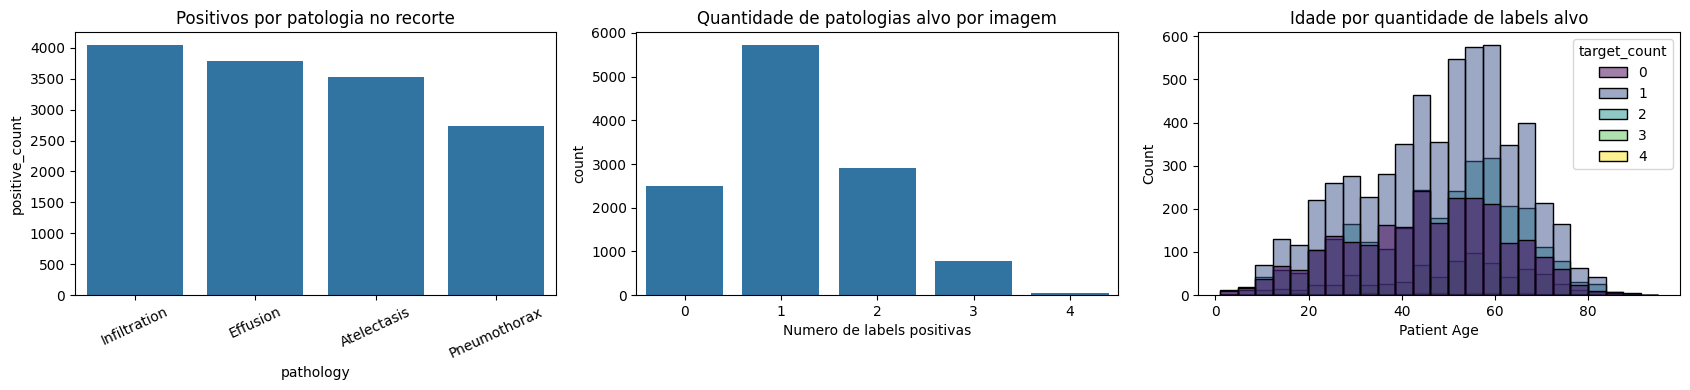

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

class_counts = dataset_df[TARGET_LABEL_COLS].sum().reset_index()
class_counts.columns = ['target_col', 'positive_count']
class_counts['pathology'] = SELECTED_PATHOLOGIES
sns.barplot(data=class_counts, x='pathology', y='positive_count', ax=axes[0])
axes[0].set_title('Positivos por patologia no recorte')
axes[0].tick_params(axis='x', rotation=25)

sns.countplot(data=dataset_df, x='target_count', ax=axes[1])
axes[1].set_title('Quantidade de patologias alvo por imagem')
axes[1].set_xlabel('Numero de labels positivas')

sns.histplot(data=dataset_df, x='Patient Age', hue='target_count', bins=25, ax=axes[2], palette='viridis')
axes[2].set_title('Idade por quantidade de labels alvo')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_recorte_modelagem_multilabel.png', dpi=160, bbox_inches='tight')
plt.show()


## 2.1. Analise exploratoria aprofundada (EDA)

Aqui investigamos distribuicao dos achados, prevalencia das quatro patologias escolhidas, quantidade de labels por imagem, idade, genero, quantidade de imagens por paciente e dimensoes reais das imagens.

Essa etapa ajuda a justificar quatro decisoes do projeto:

- usar uma tarefa multi-label em vez de uma classificacao binaria;
- escolher patologias com volume razoavel no dataset;
- fazer split por paciente para reduzir vazamento de informacao;
- incluir fairness por genero, idade e posicao da imagem.


In [11]:
# EDA geral do dataset completo apos limpeza basica e associacao com paths de imagem.

required_columns = ['Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position']
missing_required_columns = [column for column in required_columns if column not in df.columns]
if missing_required_columns:
    raise ValueError(f'Colunas obrigatorias ausentes: {missing_required_columns}')

eda_df = df.copy()
eda_df['label_count'] = eda_df['label_list'].str.len()
eda_df['is_multilabel'] = eda_df['label_count'] > 1
eda_df['selected_target_count'] = eda_df[TARGET_LABEL_COLS].sum(axis=1)
eda_df['has_any_selected_pathology'] = eda_df['selected_target_count'] > 0
eda_df['age_group'] = pd.cut(eda_df['Patient Age'], bins=[0, 18, 40, 60, 80, 120], labels=['0-18', '19-40', '41-60', '61-80', '81+'], include_lowest=True)

finding_counts = (
    eda_df[['Image Index', 'label_list']]
    .explode('label_list')
    .rename(columns={'label_list': 'finding'})
    .groupby('finding', as_index=False)['Image Index']
    .count()
    .rename(columns={'Image Index': 'image_count'})
    .sort_values('image_count', ascending=False)
)
selected_finding_counts = finding_counts[finding_counts['finding'].isin(SELECTED_PATHOLOGIES)].copy()
patient_counts = eda_df.groupby('Patient ID').size().rename('image_count_per_patient').reset_index()
null_counts = eda_df[required_columns].isna().sum().sort_values(ascending=False)

summary_rows = [
    {'metric': 'linhas totais', 'value': len(eda_df)},
    {'metric': 'imagens unicas', 'value': eda_df['Image Index'].nunique()},
    {'metric': 'pacientes unicos', 'value': eda_df['Patient ID'].nunique()},
    {'metric': 'achados unicos', 'value': finding_counts['finding'].nunique()},
    {'metric': 'imagens No Finding', 'value': int(eda_df['is_no_finding'].sum())},
    {'metric': 'imagens com qualquer patologia selecionada', 'value': int(eda_df['has_any_selected_pathology'].sum())},
    {'metric': 'imagens multi-label', 'value': int(eda_df['is_multilabel'].sum())},
    {'metric': 'media de labels originais por imagem', 'value': round(eda_df['label_count'].mean(), 3)},
    {'metric': 'media de patologias selecionadas por imagem', 'value': round(eda_df['selected_target_count'].mean(), 3)},
]
for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS):
    summary_rows.append({'metric': f'prevalencia {label}', 'value': round(eda_df[column].mean(), 4)})
    summary_rows.append({'metric': f'imagens com {label}', 'value': int(eda_df[column].sum())})

eda_summary_df = pd.DataFrame(summary_rows)
eda_summary_df.to_csv(TABLES_DIR / 'eda_validacao_e_resumo.csv', index=False)
null_counts.to_csv(TABLES_DIR / 'eda_nulos_colunas_principais.csv', header=['null_count'])
finding_counts.to_csv(TABLES_DIR / 'eda_distribuicao_achados.csv', index=False)
selected_finding_counts.to_csv(TABLES_DIR / 'eda_distribuicao_patologias_selecionadas.csv', index=False)
patient_counts.to_csv(TABLES_DIR / 'eda_imagens_por_paciente.csv', index=False)

display(eda_summary_df)
display(null_counts.to_frame('null_count'))
display(finding_counts.head(15))
display(selected_finding_counts)


,metric,value
0,linhas totais,112104.0000
1,imagens unicas,112104.0000
2,pacientes unicos,30802.0000
3,achados unicos,15.0000
4,imagens No Finding,60353.0000
5,imagens com qualquer patologia selecionada,38643.0000
6,imagens multi-label,20792.0000
7,media de labels originais por imagem,1.2620
8,media de patologias selecionadas por imagem,0.4470
9,prevalencia Infiltration,0.1774


,null_count
Image Index,0
Finding Labels,0
Patient ID,0
Patient Age,0
Patient Gender,0
View Position,0


,finding,image_count
10,No Finding,60353
8,Infiltration,19891
4,Effusion,13316
0,Atelectasis,11558
11,Nodule,6331
9,Mass,5779
14,Pneumothorax,5301
2,Consolidation,4667
12,Pleural_Thickening,3384
1,Cardiomegaly,2776


,finding,image_count
8,Infiltration,19891
4,Effusion,13316
0,Atelectasis,11558
14,Pneumothorax,5301


In [12]:
# Tabelas de foco do problema e taxas por subgrupo para as patologias selecionadas.

multilabel_focus_summary = pd.DataFrame({
    'pathology': SELECTED_PATHOLOGIES,
    'image_count': [int(eda_df[column].sum()) for column in TARGET_LABEL_COLS],
    'percentage_of_rows': [eda_df[column].mean() * 100 for column in TARGET_LABEL_COLS],
}).sort_values('image_count', ascending=False)
multilabel_focus_summary.to_csv(TABLES_DIR / 'eda_resumo_patologias_multilabel.csv', index=False)

def subgroup_rate_table(data, group_col):
    grouped = data.groupby(group_col, dropna=False).agg(
        image_count=('Image Index', 'count'),
        no_finding_count=('is_no_finding', 'sum'),
        any_selected_pathology_count=('has_any_selected_pathology', 'sum'),
        multilabel_count=('is_multilabel', 'sum'),
    ).reset_index()
    grouped['any_selected_pathology_rate'] = grouped['any_selected_pathology_count'] / grouped['image_count']
    grouped['no_finding_rate'] = grouped['no_finding_count'] / grouped['image_count']
    grouped['multilabel_rate'] = grouped['multilabel_count'] / grouped['image_count']
    for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS):
        counts = data.groupby(group_col, dropna=False)[column].sum().reset_index(name=f'{label}_count')
        grouped = grouped.merge(counts, on=group_col, how='left')
        grouped[f'{label}_rate'] = grouped[f'{label}_count'] / grouped['image_count']
    return grouped.sort_values('image_count', ascending=False)

gender_rates = subgroup_rate_table(eda_df, 'Patient Gender')
view_rates = subgroup_rate_table(eda_df, 'View Position')
age_rates = subgroup_rate_table(eda_df, 'age_group')

gender_rates.to_csv(TABLES_DIR / 'eda_taxas_por_genero.csv', index=False)
view_rates.to_csv(TABLES_DIR / 'eda_taxas_por_posicao_imagem.csv', index=False)
age_rates.to_csv(TABLES_DIR / 'eda_taxas_por_faixa_etaria.csv', index=False)

display(multilabel_focus_summary)
display(gender_rates)
display(view_rates)
display(age_rates)


,pathology,image_count,percentage_of_rows
0,Infiltration,19891,17.743345
1,Effusion,13316,11.878256
2,Atelectasis,11558,10.310069
3,Pneumothorax,5301,4.728645


,Patient Gender,image_count,no_finding_count,any_selected_pathology_count,multilabel_count,any_selected_pathology_rate,no_finding_rate,multilabel_rate,Infiltration_count,Infiltration_rate,Effusion_count,Effusion_rate,Atelectasis_count,Atelectasis_rate,Pneumothorax_count,Pneumothorax_rate
1,M,63328,33916,21905,11993,0.345898,0.535561,0.189379,11425,0.180410,7434,0.117389,6905,0.109035,2717,0.042904
0,F,48776,26437,16738,8799,0.343161,0.542008,0.180396,8466,0.173569,5882,0.120592,4653,0.095395,2584,0.052977


,View Position,image_count,no_finding_count,any_selected_pathology_count,multilabel_count,any_selected_pathology_rate,no_finding_rate,multilabel_rate,Infiltration_count,Infiltration_rate,Effusion_count,Effusion_rate,Atelectasis_count,Atelectasis_rate,Pneumothorax_count,Pneumothorax_rate
1,PA,67299,39296,19986,10178,0.296973,0.583902,0.151236,9350,0.138932,6589,0.097906,5727,0.085098,3406,0.050610
0,AP,44805,21057,18657,10614,0.416404,0.469970,0.236893,10541,0.235264,6727,0.150139,5831,0.130142,1895,0.042294


,age_group,image_count,no_finding_count,any_selected_pathology_count,multilabel_count,any_selected_pathology_rate,no_finding_rate,multilabel_rate,Infiltration_count,Infiltration_rate,Effusion_count,Effusion_rate,Atelectasis_count,Atelectasis_rate,Pneumothorax_count,Pneumothorax_rate
2,41-60,49502,26386,17195,9346,0.347360,0.533029,0.188800,8483,0.171367,6084,0.122904,5579,0.112703,2257,0.045594
1,19-40,32014,18525,10243,5253,0.319954,0.578653,0.164084,5921,0.184950,3165,0.098863,2414,0.075405,1471,0.045949
3,61-80,23766,11589,8932,4985,0.375831,0.487629,0.209753,4140,0.174198,3423,0.144029,3057,0.128629,1169,0.049188
0,0-18,5941,3479,1930,984,0.324861,0.585592,0.165629,1181,0.198788,506,0.085171,391,0.065814,361,0.060764
4,81+,881,374,343,224,0.389330,0.424518,0.254257,166,0.188422,138,0.156640,117,0.132804,43,0.048808


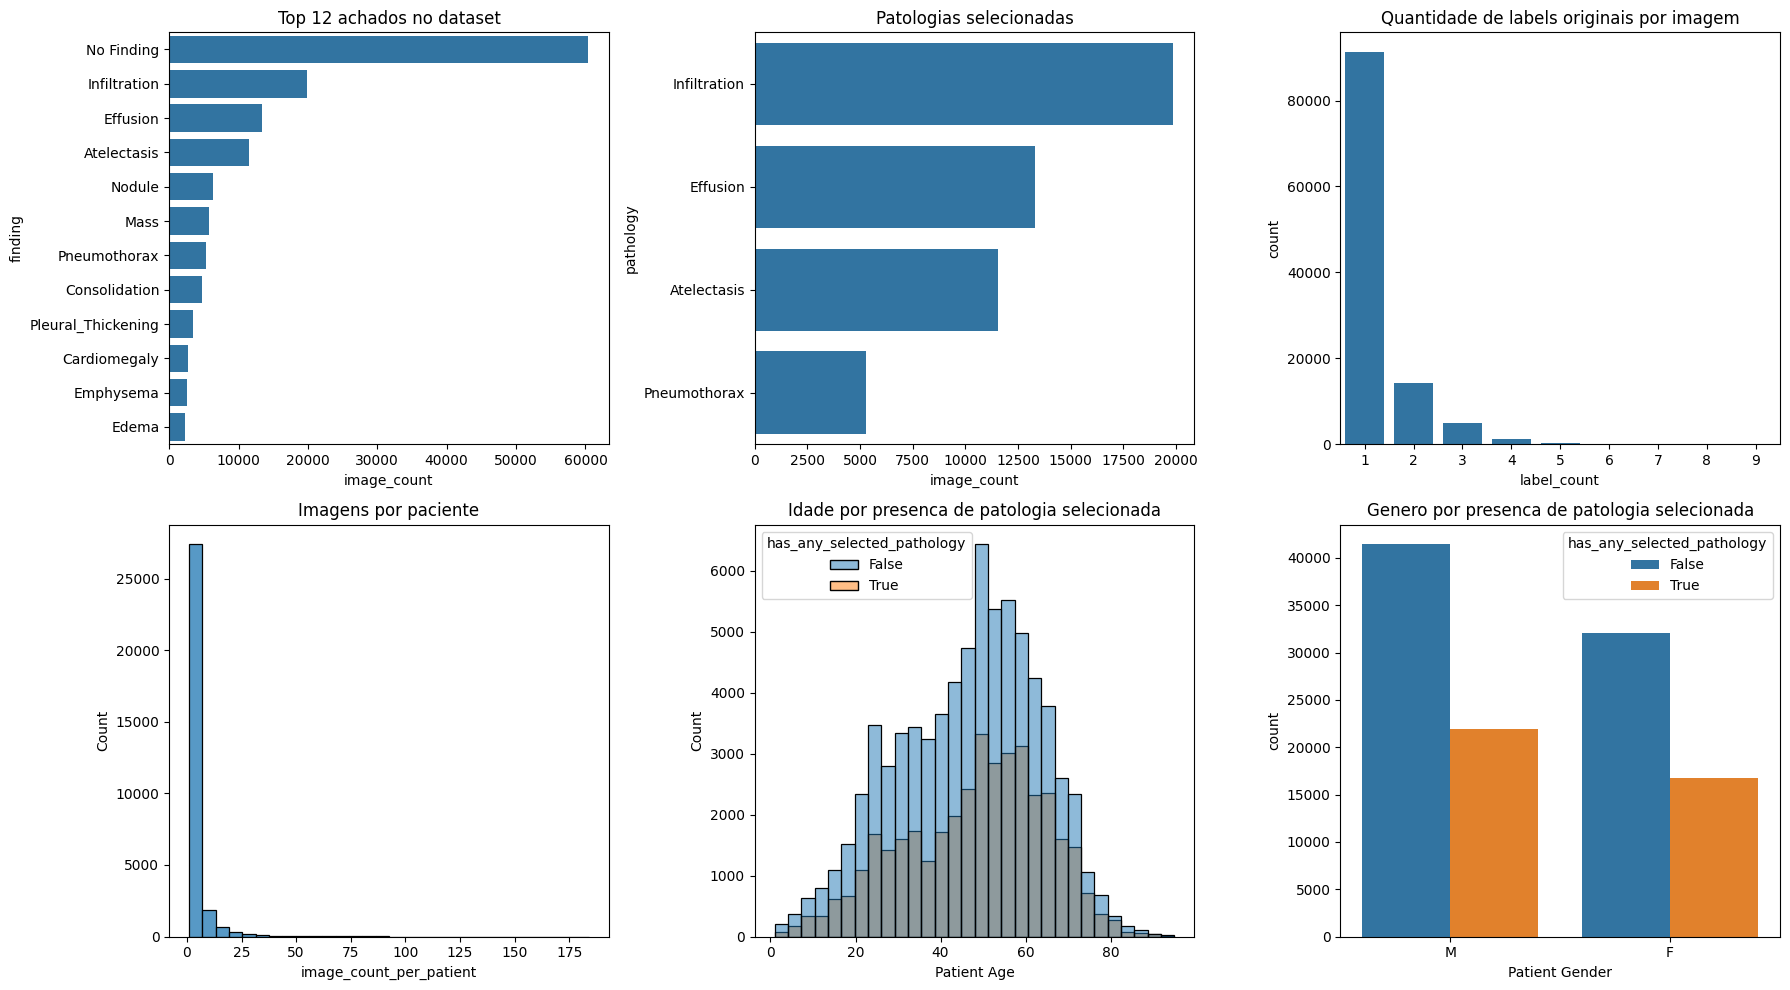

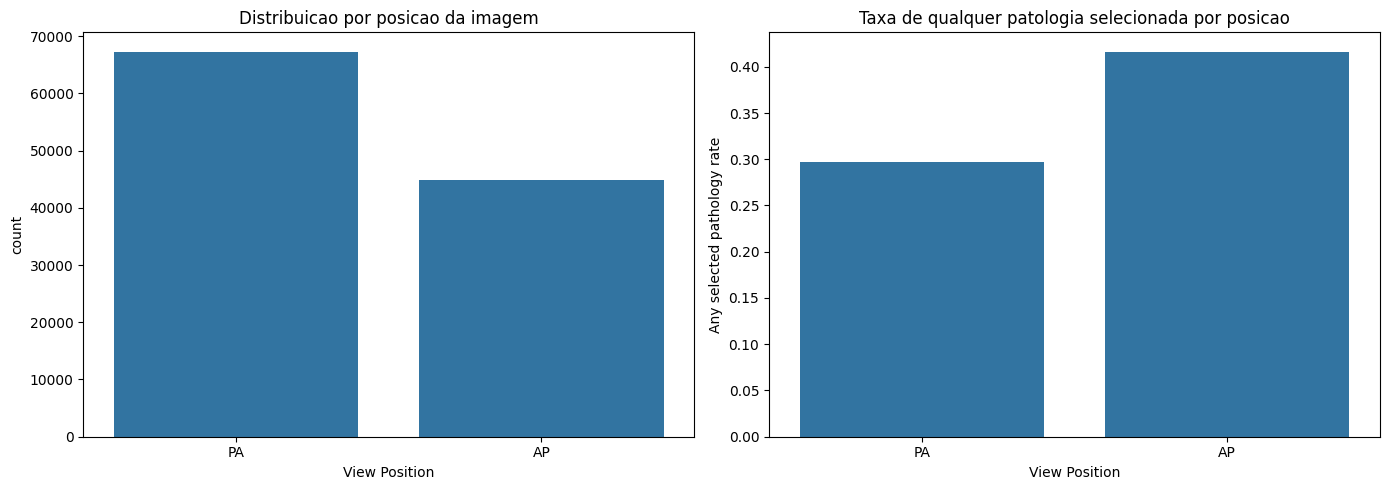

In [13]:
# Visualizacoes exploratorias do dataset completo.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.barplot(data=finding_counts.head(12), y='finding', x='image_count', ax=axes[0, 0])
axes[0, 0].set_title('Top 12 achados no dataset')
sns.barplot(data=multilabel_focus_summary, y='pathology', x='image_count', ax=axes[0, 1])
axes[0, 1].set_title('Patologias selecionadas')
sns.countplot(data=eda_df, x='label_count', ax=axes[0, 2])
axes[0, 2].set_title('Quantidade de labels originais por imagem')
sns.histplot(data=patient_counts, x='image_count_per_patient', bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Imagens por paciente')
sns.histplot(data=eda_df, x='Patient Age', hue='has_any_selected_pathology', bins=30, ax=axes[1, 1])
axes[1, 1].set_title('Idade por presenca de patologia selecionada')
sns.countplot(data=eda_df, x='Patient Gender', hue='has_any_selected_pathology', ax=axes[1, 2])
axes[1, 2].set_title('Genero por presenca de patologia selecionada')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_visao_geral_dataset.png', dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=eda_df, x='View Position', ax=axes[0])
axes[0].set_title('Distribuicao por posicao da imagem')
sns.barplot(data=view_rates, x='View Position', y='any_selected_pathology_rate', ax=axes[1])
axes[1].set_title('Taxa de qualquer patologia selecionada por posicao')
axes[1].set_ylabel('Any selected pathology rate')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_posicao_imagem.png', dpi=160, bbox_inches='tight')
plt.show()


,Infiltration,Effusion,Atelectasis,Pneumothorax
Patient Gender,,,,
F,1761,1707,1429,1308
M,2287,2076,2101,1421


,Infiltration,Effusion,Atelectasis,Pneumothorax
age_group,,,,
0-18,224,165,124,196
19-40,1153,872,720,739
41-60,1788,1734,1730,1159
61-80,858,983,921,613
81+,25,29,35,22


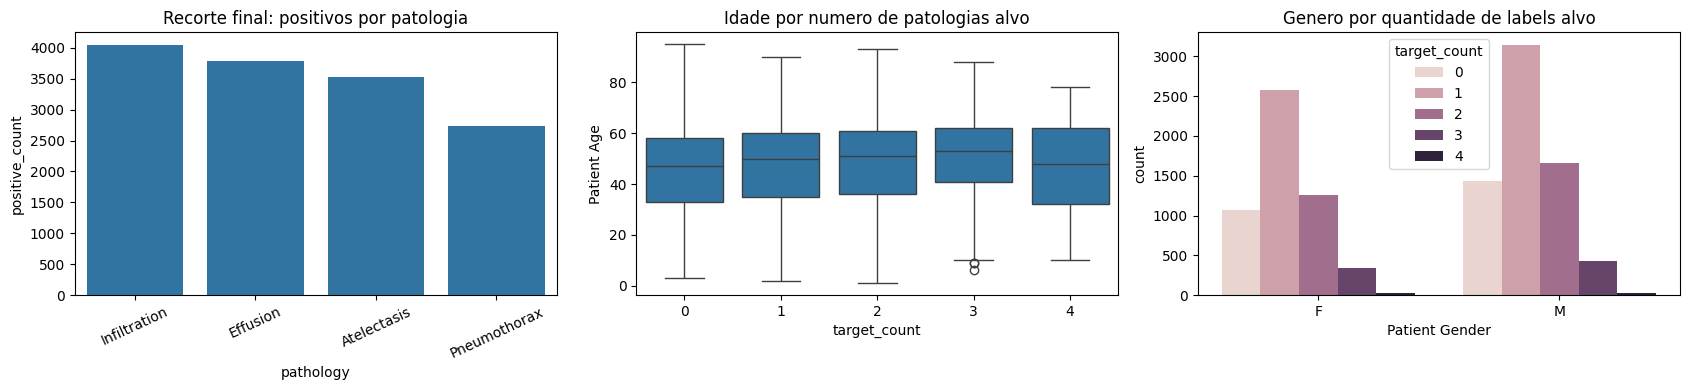

In [14]:
# EDA focada no recorte usado para modelagem.

model_eda = dataset_df.copy()
model_eda['age_group'] = pd.cut(model_eda['Patient Age'], bins=[0, 18, 40, 60, 80, 120], labels=['0-18', '19-40', '41-60', '61-80', '81+'], include_lowest=True)

class_by_gender = pd.DataFrame({label: model_eda.groupby('Patient Gender')[column].sum() for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS)})
class_by_age = pd.DataFrame({label: model_eda.groupby('age_group', observed=False)[column].sum() for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS)})
display(class_by_gender)
display(class_by_age)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
class_counts = model_eda[TARGET_LABEL_COLS].sum().reset_index()
class_counts.columns = ['target_col', 'positive_count']
class_counts['pathology'] = SELECTED_PATHOLOGIES
sns.barplot(data=class_counts, x='pathology', y='positive_count', ax=axes[0])
axes[0].set_title('Recorte final: positivos por patologia')
axes[0].tick_params(axis='x', rotation=25)
sns.boxplot(data=model_eda, x='target_count', y='Patient Age', ax=axes[1])
axes[1].set_title('Idade por numero de patologias alvo')
sns.countplot(data=model_eda, x='Patient Gender', hue='target_count', ax=axes[2])
axes[2].set_title('Genero por quantidade de labels alvo')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_recorte_modelagem_detalhe.png', dpi=160, bbox_inches='tight')
plt.show()


,width,height,mode
count,200.0,200.0,200
unique,NaN,NaN,1
top,NaN,NaN,L
freq,NaN,NaN,200
mean,1024.0,1024.0,NaN
std,0.0,0.0,NaN
min,1024.0,1024.0,NaN
25%,1024.0,1024.0,NaN
50%,1024.0,1024.0,NaN
75%,1024.0,1024.0,NaN


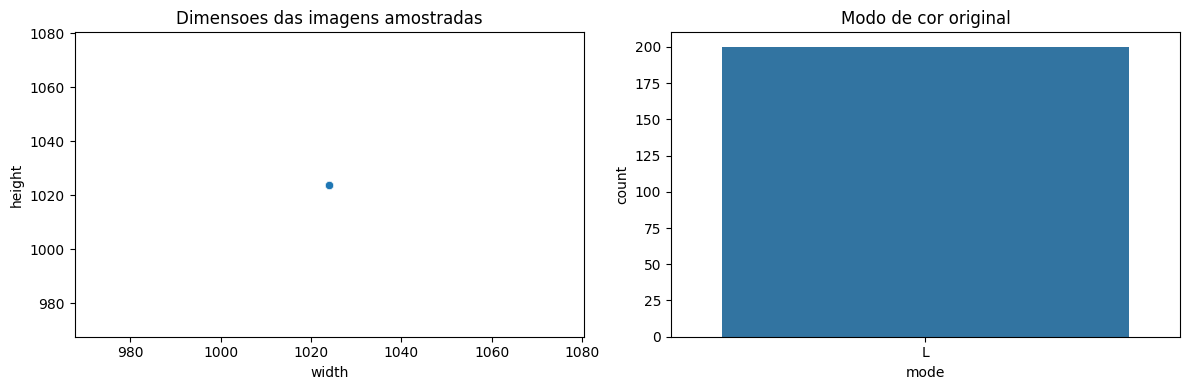

In [15]:
# Inspecao de dimensoes das imagens. Amostramos algumas imagens para confirmar padrao visual e necessidade de resize.

sample_paths = model_eda['path'].sample(n=min(200, len(model_eda)), random_state=SEED)
image_shape_rows = []
for path in sample_paths:
    with Image.open(path) as img:
        image_shape_rows.append({'width': img.width, 'height': img.height, 'mode': img.mode})

image_shapes_df = pd.DataFrame(image_shape_rows)
display(image_shapes_df.describe(include='all'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=image_shapes_df, x='width', y='height', ax=axes[0])
axes[0].set_title('Dimensoes das imagens amostradas')
sns.countplot(data=image_shapes_df, x='mode', ax=axes[1])
axes[1].set_title('Modo de cor original')
plt.tight_layout()
plt.show()

### Leituras esperadas da EDA

- `No Finding` representa 60.353 imagens, cerca de 53,84% das linhas analisadas, e funciona como negativo para as quatro patologias alvo.
- As quatro patologias escolhidas possuem prevalencias diferentes: `Infiltration` tem 19.891 imagens, `Effusion` 13.316, `Atelectasis` 11.558 e `Pneumothorax` 5.301. Esse desbalanceamento justifica o uso de `pos_weight` e metricas macro.
- O dataset e multi-label: 20.792 imagens possuem mais de uma label original e 9.667 possuem mais de uma das quatro patologias selecionadas. Isso sustenta a decisao de nao tratar o problema como classificacao binaria simples.
- A quantidade de imagens por paciente reforca a necessidade do split por `Patient ID`, evitando que imagens do mesmo paciente aparecam em treino e teste.
- Diferencas por idade, genero e `View Position` justificam a etapa posterior de fairness; esses atributos nao sao usados como entrada visual do modelo, mas sao importantes para auditoria.
- A analise de dimensoes confirma a necessidade de redimensionamento padronizado para entrada dos modelos.


In [16]:
# Conclusoes objetivas da EDA para apoiar o relatorio tecnico.

total_rows = len(eda_df)
multilabel_count = int(eda_df['is_multilabel'].sum())
selected_multilabel_count = int((eda_df['selected_target_count'] > 1).sum())

eda_conclusions = [
    {'question': 'O dataset e balanceado?', 'answer': 'Nao. A distribuicao de achados mostra diferencas importantes entre as patologias, justificando pos_weight por classe no treino multi-label.'},
    {'question': 'Quantas imagens No Finding existem?', 'answer': f"{int(eda_df['is_no_finding'].sum()):,} imagens ({eda_df['is_no_finding'].mean():.2%} das linhas analisadas). Elas sao usadas como negativos para as quatro patologias alvo."},
    {'question': 'Quais patologias foram selecionadas?', 'answer': ', '.join([f'{label}: {int(eda_df[column].sum()):,}' for label, column in zip(SELECTED_PATHOLOGIES, TARGET_LABEL_COLS)])},
    {'question': 'Existem casos multi-label relevantes?', 'answer': f'{multilabel_count:,} imagens possuem mais de uma label original ({multilabel_count / total_rows:.2%}); {selected_multilabel_count:,} possuem mais de uma patologia entre as quatro selecionadas.'},
    {'question': 'Por que usar split por paciente?', 'answer': 'Ha pacientes com multiplas imagens. Separar por Patient ID reduz o risco de vazamento entre treino, validacao e teste.'},
    {'question': 'Quais variaveis entram na discussao de governanca?', 'answer': 'Genero, idade e View Position mostram distribuicoes/taxas diferentes e devem ser monitorados na avaliacao e fairness.'},
]

eda_conclusions_df = pd.DataFrame(eda_conclusions)
eda_conclusions_df.to_csv(TABLES_DIR / 'eda_conclusoes.csv', index=False)
display(eda_conclusions_df)
print('Tabelas e figuras da EDA salvas em:', ARTIFACT_DIR.resolve())


,question,answer
0,O dataset e balanceado?,Nao. A distribuicao de achados mostra diferenc...
1,Quantas imagens No Finding existem?,"60,353 imagens (53.84% das linhas analisadas)...."
2,Quais patologias foram selecionadas?,"Infiltration: 19,891, Effusion: 13,316, Atelec..."
3,Existem casos multi-label relevantes?,"20,792 imagens possuem mais de uma label origi..."
4,Por que usar split por paciente?,Ha pacientes com multiplas imagens. Separar po...
5,Quais variaveis entram na discussao de governa...,"Genero, idade e View Position mostram distribu..."


Tabelas e figuras da EDA salvas em: C:\FIAP\fase4\fiap_fase4\notebooks\artifacts_cardioia_pytorch_multilabel


## 3. Split por paciente

Para evitar vazamento de informacao, imagens do mesmo paciente nao devem aparecer simultaneamente em treino e teste. Usamos `Patient ID` como grupo.

In [17]:
def group_split(dataframe, test_size, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(splitter.split(dataframe, groups=dataframe['Patient ID']))
    return dataframe.iloc[train_idx].copy(), dataframe.iloc[test_idx].copy()

train_df, temp_df = group_split(dataset_df, test_size=0.30, seed=SEED)
val_df, test_df = group_split(temp_df, test_size=0.50, seed=SEED + 1)

for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    class_rates = split_df[TARGET_LABEL_COLS].mean().rename(index=dict(zip(TARGET_LABEL_COLS, SELECTED_PATHOLOGIES))).round(3).to_dict()
    print(name, split_df.shape, class_rates, 'pacientes:', split_df['Patient ID'].nunique())

train_df.to_csv(ARTIFACT_DIR / 'train_split.csv', index=False)
val_df.to_csv(ARTIFACT_DIR / 'val_split.csv', index=False)
test_df.to_csv(ARTIFACT_DIR / 'test_split.csv', index=False)


train (8363, 21) {'Infiltration': 0.335, 'Effusion': 0.317, 'Atelectasis': 0.298, 'Pneumothorax': 0.227} pacientes: 4208
val (1688, 21) {'Infiltration': 0.363, 'Effusion': 0.32, 'Atelectasis': 0.286, 'Pneumothorax': 0.199} pacientes: 902
test (1914, 21) {'Infiltration': 0.333, 'Effusion': 0.311, 'Atelectasis': 0.291, 'Pneumothorax': 0.258} pacientes: 902


## 4. Dataset, transforms e DataLoader

Pre-processamento aplicado:

- leitura da imagem PNG;
- conversao para RGB;
- redimensionamento para 224x224;
- transformacao para tensor;
- normalizacao ImageNet para compatibilidade com modelos pre-treinados;
- data augmentation apenas no treino;
- retorno de vetor multi-label com quatro posicoes, uma para cada patologia selecionada.


torch.Size([128, 3, 224, 224]) torch.Size([128, 4])


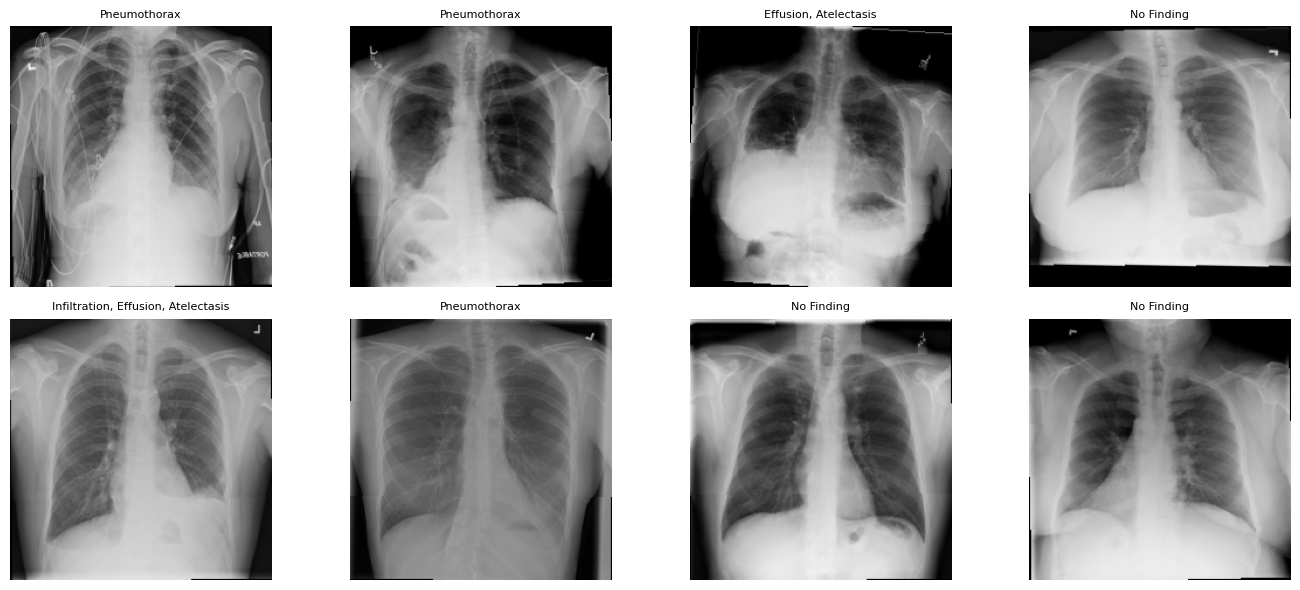

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        with Image.open(row['path']) as img:
            image = img.convert('RGB')
        if self.transform:
            image = self.transform(image)
        labels = torch.tensor(row[TARGET_LABEL_COLS].to_numpy(dtype=np.float32), dtype=torch.float32)
        return image, labels

def make_loader(dataframe, transform, shuffle=False):
    ds = ChestXrayDataset(dataframe, transform=transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

train_loader = make_loader(train_df, train_transform, shuffle=True)
val_loader = make_loader(val_df, eval_transform)
test_loader = make_loader(test_df, eval_transform)

batch_images, batch_labels = next(iter(train_loader))
print(batch_images.shape, batch_labels.shape)

plt.figure(figsize=(14, 6))
for i in range(min(8, len(batch_images))):
    image = batch_images[i].permute(1, 2, 0).numpy()
    image = image * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    image = np.clip(image, 0, 1)
    labels = [label for label, value in zip(SELECTED_PATHOLOGIES, batch_labels[i].numpy()) if value == 1]
    title = ', '.join(labels) if labels else NEGATIVE_LABEL
    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(title, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


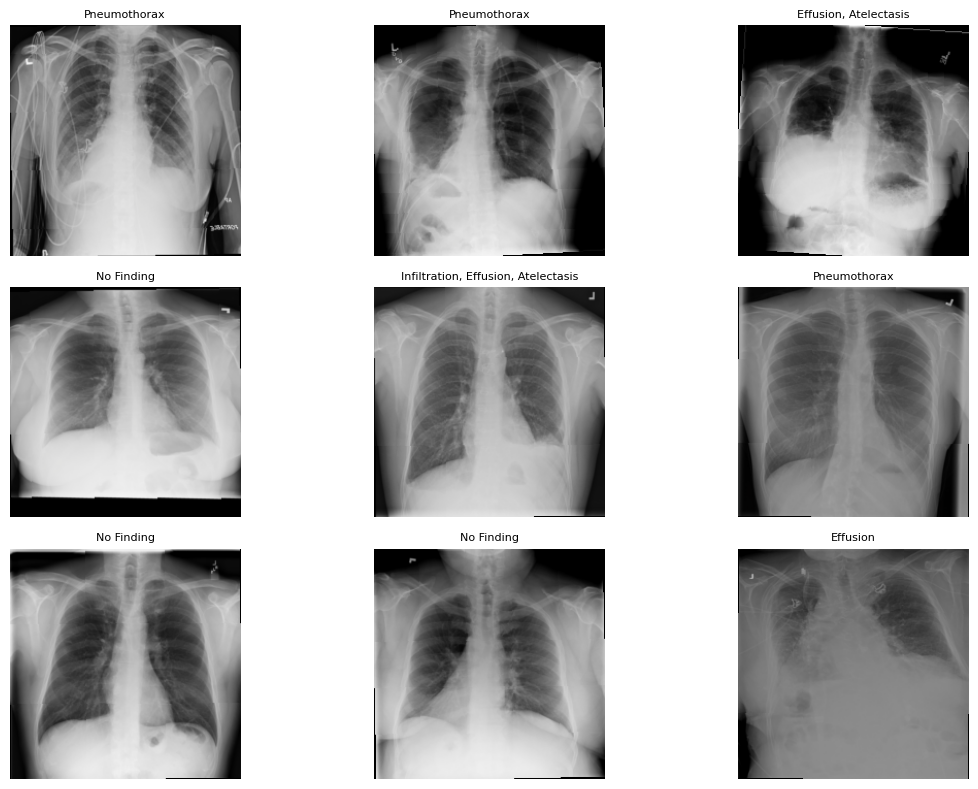

In [19]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 8))
for i in range(min(9, len(batch_images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(denormalize(batch_images[i]))
    labels = [label for label, value in zip(SELECTED_PATHOLOGIES, batch_labels[i].numpy()) if value == 1]
    plt.title(', '.join(labels) if labels else NEGATIVE_LABEL, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


## 5. Funcoes de treino e avaliacao

Todos os modelos retornam **quatro logits**, um para cada patologia selecionada. Usamos `BCEWithLogitsLoss`, `sigmoid` na avaliacao e threshold padrao de 0.5 para converter probabilidades em labels multi-label.


In [20]:
pos_count = train_df[TARGET_LABEL_COLS].sum()
neg_count = len(train_df) - pos_count
POS_WEIGHT = torch.tensor((neg_count / pos_count.clip(lower=1)).values, dtype=torch.float32).to(DEVICE)
print('pos_weight por classe:')
display(pd.DataFrame({'pathology': SELECTED_PATHOLOGIES, 'pos_weight': POS_WEIGHT.detach().cpu().numpy()}))

DEBUG_DEVICE_ONCE = True

def train_one_epoch(model, loader, optimizer, criterion, scaler=None):
    global DEBUG_DEVICE_ONCE
    model.train()
    total_loss = 0.0
    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        if DEBUG_DEVICE_ONCE:
            print('Device do modelo:', next(model.parameters()).device)
            print('Device das imagens:', images.device)
            print('Device dos labels:', labels.device)
            print_gpu_status('Durante o treino:')
            DEBUG_DEVICE_ONCE = False
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, labels)
        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def predict_proba(model, loader):
    model.eval()
    y_true, y_proba = [], []
    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        logits = model(images).detach().cpu()
        probs = torch.sigmoid(logits).numpy()
        y_proba.append(probs)
        y_true.append(labels.numpy().astype(int))
    return np.vstack(y_true), np.vstack(y_proba)

def safe_roc_auc(y_true, y_proba, average):
    try:
        return roc_auc_score(y_true, y_proba, average=average)
    except ValueError:
        return np.nan

def safe_average_precision(y_true, y_proba, average):
    try:
        return average_precision_score(y_true, y_proba, average=average)
    except ValueError:
        return np.nan

def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    ml_cm = multilabel_confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    tn = ml_cm[:, 0, 0]
    fp = ml_cm[:, 0, 1]
    fn = ml_cm[:, 1, 0]
    tp = ml_cm[:, 1, 1]
    specificity_per_class = tn / np.maximum(tn + fp, 1)
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'hamming_loss': hamming_loss(y_true, y_pred),
        'precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'f1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'specificity_macro': float(np.mean(specificity_per_class)),
        'roc_auc_macro': safe_roc_auc(y_true, y_proba, average='macro'),
        'roc_auc_micro': safe_roc_auc(y_true, y_proba, average='micro'),
        'pr_auc_macro': safe_average_precision(y_true, y_proba, average='macro'),
        'pr_auc_micro': safe_average_precision(y_true, y_proba, average='micro'),
        'tn_total': int(tn.sum()), 'fp_total': int(fp.sum()), 'fn_total': int(fn.sum()), 'tp_total': int(tp.sum()),
        'threshold': threshold,
    }
    metrics['precision'] = metrics['precision_macro']
    metrics['recall'] = metrics['recall_macro']
    metrics['f1'] = metrics['f1_macro']
    metrics['specificity'] = metrics['specificity_macro']
    metrics['roc_auc'] = metrics['roc_auc_macro']
    metrics['pr_auc'] = metrics['pr_auc_macro']
    return metrics

def per_class_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    ml_cm = multilabel_confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    rows = []
    for idx, label in enumerate(SELECTED_PATHOLOGIES):
        tn, fp, fn, tp = ml_cm[idx].ravel()
        auc = roc_auc_score(y_true[:, idx], y_proba[:, idx]) if len(np.unique(y_true[:, idx])) == 2 else np.nan
        pr_auc = average_precision_score(y_true[:, idx], y_proba[:, idx]) if len(np.unique(y_true[:, idx])) == 2 else np.nan
        rows.append({
            'pathology': label,
            'support_positive': int(y_true[:, idx].sum()),
            'support_negative': int((1 - y_true[:, idx]).sum()),
            'precision': precision_score(y_true[:, idx], y_pred[:, idx], zero_division=0),
            'recall': recall_score(y_true[:, idx], y_pred[:, idx], zero_division=0),
            'f1': f1_score(y_true[:, idx], y_pred[:, idx], zero_division=0),
            'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
            'roc_auc': auc,
            'pr_auc': pr_auc,
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        })
    return pd.DataFrame(rows)

def plot_confusion(y_true, y_proba, title, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    ml_cm = multilabel_confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
    if NUM_CLASSES == 1:
        axes = [axes]
    for ax, label, cm in zip(axes, SELECTED_PATHOLOGIES, ml_cm):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'], ax=ax)
        ax.set_title(label)
        ax.set_xlabel('Previsto')
        ax.set_ylabel('Real')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def fit_model(model, model_name, epochs, lr=1e-3, weight_decay=1e-4):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=2)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    best_state = None
    best_val_f1 = -1
    history = []
    patience = 4
    patience_left = patience

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        y_val, p_val = predict_proba(model, val_loader)
        val_metrics = compute_metrics(y_val, p_val)
        scheduler.step(val_metrics['f1_macro'])
        row = {'epoch': epoch, 'train_loss': train_loss, **val_metrics}
        history.append(row)
        print(f"{model_name} | epoch {epoch}/{epochs} | loss={train_loss:.4f} | val_f1_macro={val_metrics['f1_macro']:.4f} | val_auc_macro={val_metrics['roc_auc_macro']:.4f}")
        if val_metrics['f1_macro'] > best_val_f1:
            best_val_f1 = val_metrics['f1_macro']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print('Early stopping')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

experiment_results = []
predictions_registry = {}
trained_models_registry = {}

def count_parameters(model):
    total_parameters = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total_parameters, trainable_parameters

@torch.no_grad()
def benchmark_inference(model, loader, max_batches=10):
    model.eval()
    total_images = 0
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()
    for batch_index, (images, _) in enumerate(loader):
        if batch_index >= max_batches:
            break
        images = images.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            _ = model(images)
        total_images += images.size(0)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed_time = time.perf_counter() - start_time
    return elapsed_time / max(total_images, 1)

def evaluate_model(model, model_name):
    model = model.to(DEVICE)
    y_true, y_proba = predict_proba(model, test_loader)
    metrics = compute_metrics(y_true, y_proba)
    class_metrics = per_class_metrics(y_true, y_proba)
    total_parameters, trainable_parameters = count_parameters(model)
    checkpoint_path = MODELS_DIR / f'{model_name.replace(" ", "_").lower()}.pt'
    torch.save(model.state_dict(), checkpoint_path)
    metrics['model'] = model_name
    metrics['model_name'] = model_name
    metrics['auc_roc'] = metrics['roc_auc_macro']
    metrics['seconds_per_image'] = benchmark_inference(model, test_loader)
    metrics['total_parameters'] = total_parameters
    metrics['trainable_parameters'] = trainable_parameters
    metrics['checkpoint_path'] = str(checkpoint_path)
    metrics['checkpoint_size_bytes'] = checkpoint_path.stat().st_size if checkpoint_path.exists() else np.nan
    experiment_results.append(metrics)
    trained_models_registry[model_name] = model

    pred_df = pd.DataFrame({
        'Image Index': test_df['Image Index'].values,
        'Patient ID': test_df['Patient ID'].values,
        'Patient Gender': test_df['Patient Gender'].values,
        'Patient Age': test_df['Patient Age'].values,
        'View Position': test_df['View Position'].values,
    })
    y_pred = (y_proba >= 0.5).astype(int)
    for idx, label in enumerate(SELECTED_PATHOLOGIES):
        safe_label = label.lower()
        pred_df[f'true_{safe_label}'] = y_true[:, idx]
        pred_df[f'proba_{safe_label}'] = y_proba[:, idx]
        pred_df[f'pred_{safe_label}'] = y_pred[:, idx]
    pred_df['y_true_any'] = (y_true.sum(axis=1) > 0).astype(int)
    pred_df['y_pred_any'] = (y_pred.sum(axis=1) > 0).astype(int)
    pred_df['y_proba_max'] = y_proba.max(axis=1)
    predictions_registry[model_name] = pred_df

    class_metrics.to_csv(TABLES_DIR / f'metricas_por_classe_{model_name.replace(" ", "_").lower()}.csv', index=False)
    print(model_name)
    print(classification_report(y_true, y_pred, target_names=SELECTED_PATHOLOGIES, zero_division=0))
    display(class_metrics)
    print(f"Inferencia media: {metrics['seconds_per_image']:.6f} s/imagem | Parametros: {total_parameters:,} | Checkpoint: {metrics['checkpoint_size_bytes'] / (1024 ** 2):.2f} MB")
    plot_confusion(y_true, y_proba, f'Matrizes de confusao por patologia - {model_name}')
    return metrics


pos_weight por classe:


,pathology,pos_weight
0,Infiltration,1.987853
1,Effusion,2.158233
2,Atelectasis,2.358634
3,Pneumothorax,3.403897


## 6. Modelo 1 - CNN base do zero

Este e o algoritmo base pedido no enunciado: uma CNN simples treinada do zero. A ultima camada possui quatro saidas, uma para cada patologia alvo.


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/66 [00:00<?, ?it/s]

Device do modelo: cuda:0
Device das imagens: cuda:0
Device dos labels: cuda:0
Durante o treino: DEVICE = cuda
Durante o treino: GPU = NVIDIA GeForce RTX 5070 Ti
Durante o treino: Memoria alocada MB = 124.4
Durante o treino: Memoria reservada MB = 126.0


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN base | epoch 1/8 | loss=0.9970 | val_f1_macro=0.4206 | val_auc_macro=0.6351


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

,epoch,train_loss,accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,...,fp_total,fn_total,tp_total,threshold,precision,recall,f1,specificity,roc_auc,pr_auc
0,1,0.997023,0.174763,0.362115,0.405427,0.515474,0.453875,0.412106,0.500993,0.420551,...,1490,955,1016,0.5,0.412106,0.500993,0.420551,0.685712,0.635126,0.402133
1,2,0.932853,0.140995,0.392032,0.386348,0.582953,0.464712,0.401637,0.593193,0.465293,...,1825,822,1149,0.5,0.401637,0.593193,0.465293,0.625899,0.646730,0.415291
2,3,0.924356,0.151659,0.384034,0.397563,0.612380,0.482125,0.389461,0.600043,0.470150,...,1829,764,1207,0.5,0.389461,0.600043,0.470150,0.615665,0.654236,0.422771
3,4,0.916620,0.120261,0.408916,0.385640,0.675799,0.491060,0.375195,0.660155,0.476949,...,2122,639,1332,0.5,0.375195,0.660155,0.476949,0.550831,0.656553,0.429095
4,5,0.913436,0.154621,0.379295,0.408894,0.671740,0.508351,0.392735,0.624826,0.469496,...,1914,647,1324,0.5,0.392735,0.624826,0.469496,0.582615,0.659921,0.434339
5,6,0.908284,0.172986,0.364040,0.409982,0.562659,0.474337,0.405171,0.557067,0.464755,...,1596,862,1109,0.5,0.405171,0.557067,0.464755,0.665881,0.652955,0.422979
6,7,0.905928,0.147512,0.385219,0.396924,0.615424,0.482594,0.393546,0.607177,0.465574,...,1843,758,1213,0.5,0.393546,0.607177,0.465574,0.613666,0.662470,0.434203
7,8,0.893131,0.180095,0.354265,0.424035,0.596144,0.495571,0.411212,0.577116,0.472783,...,1596,796,1175,0.5,0.411212,0.577116,0.472783,0.661329,0.666266,0.443951


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN base
              precision    recall  f1-score   support

Infiltration       0.40      0.69      0.50       637
    Effusion       0.38      0.82      0.52       595
 Atelectasis       0.40      0.61      0.48       557
Pneumothorax       0.38      0.61      0.47       494

   micro avg       0.39      0.69      0.50      2283
   macro avg       0.39      0.68      0.49      2283
weighted avg       0.39      0.69      0.50      2283
 samples avg       0.35      0.54      0.40      2283



,pathology,support_positive,support_negative,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Infiltration,637,1277,0.398367,0.689168,0.504888,0.480814,0.642823,0.482641,614,663,198,439
1,Effusion,595,1319,0.381847,0.820168,0.521089,0.401061,0.687205,0.466294,529,790,107,488
2,Atelectasis,557,1357,0.396714,0.606822,0.479773,0.621223,0.653992,0.416277,843,514,219,338
3,Pneumothorax,494,1420,0.378750,0.613360,0.468315,0.650000,0.682828,0.415577,923,497,191,303


Inferencia media: 0.011012 s/imagem | Parametros: 12,938,948 | Checkpoint: 49.36 MB


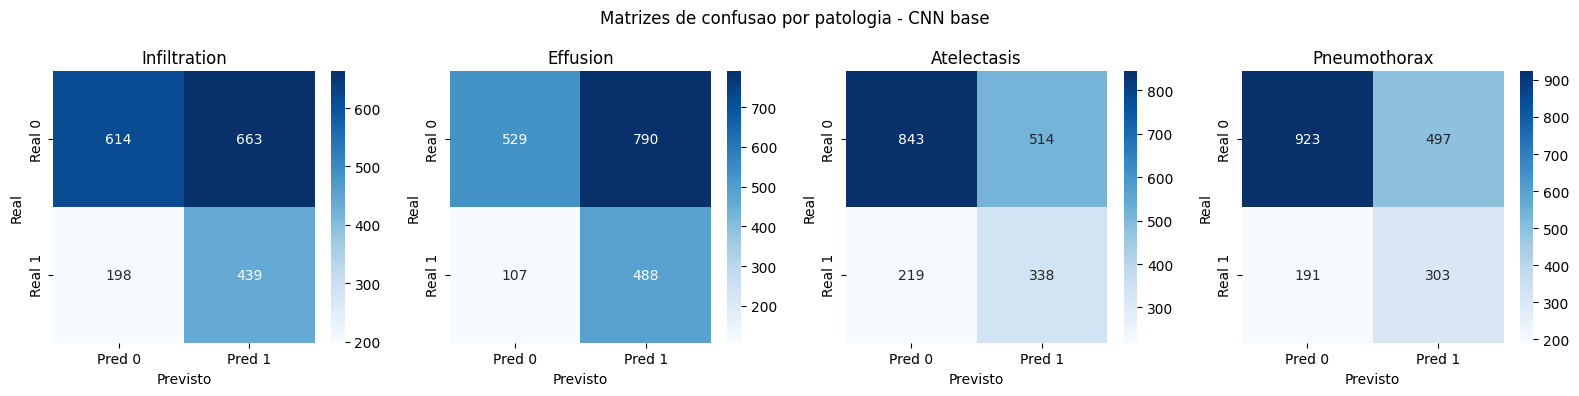

In [21]:
class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128), nn.ReLU(),
            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

base_cnn = BaseCNN()
if RUN_FULL_TRAINING:
    base_cnn, history_base = fit_model(base_cnn, 'CNN base', EPOCHS_BASE, lr=1e-3)
    display(history_base)
    evaluate_model(base_cnn, 'CNN base')

## 7. Modelo 2 - CNN melhorada

Melhorias aplicadas sobre a CNN base: BatchNorm2d, Dropout, AdaptiveAvgPool2d, AdamW, pos_weight por patologia, augmentation e early stopping por F1 macro de validacao.


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN melhorada | epoch 1/12 | loss=0.9622 | val_f1_macro=0.4331 | val_auc_macro=0.5969


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN melhorada | epoch 2/12 | loss=0.9445 | val_f1_macro=0.4638 | val_auc_macro=0.6348


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

,epoch,train_loss,accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,...,fp_total,fn_total,tp_total,threshold,precision,recall,f1,specificity,roc_auc,pr_auc
0,1,0.962221,0.044431,0.540581,0.328638,0.816844,0.468705,0.318452,0.763026,0.433052,...,3289,361,1610,0.5,0.318452,0.763026,0.433052,0.287928,0.596899,0.368810
1,2,0.944450,0.055095,0.530213,0.330596,0.796550,0.467262,0.334881,0.805074,0.463756,...,3179,401,1570,0.5,0.334881,0.805074,0.463756,0.336871,0.634804,0.402976
2,3,0.937380,0.026659,0.632405,0.305664,0.917301,0.458534,0.303850,0.916033,0.453558,...,4107,163,1808,0.5,0.303850,0.916033,0.453558,0.138020,0.572650,0.341289
3,4,0.931005,0.194905,0.368187,0.384581,0.435312,0.408377,0.394558,0.449667,0.402763,...,1373,1113,858,0.5,0.394558,0.449667,0.402763,0.716774,0.636254,0.402643
4,5,0.925463,0.231043,0.295024,0.343284,0.011669,0.022571,0.085821,0.017113,0.028536,...,44,1948,23,0.5,0.085821,0.017113,0.028536,0.991864,0.574779,0.340126
5,6,0.912499,0.180095,0.366706,0.409982,0.583460,0.481575,0.403023,0.555077,0.460094,...,1655,821,1150,0.5,0.403023,0.555077,0.460094,0.643129,0.655245,0.432229


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


CNN melhorada
              precision    recall  f1-score   support

Infiltration       0.40      0.66      0.49       637
    Effusion       0.34      0.93      0.50       595
 Atelectasis       0.33      0.84      0.47       557
Pneumothorax       0.33      0.83      0.47       494

   micro avg       0.34      0.81      0.48      2283
   macro avg       0.35      0.81      0.48      2283
weighted avg       0.35      0.81      0.48      2283
 samples avg       0.33      0.64      0.41      2283



,pathology,support_positive,support_negative,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Infiltration,637,1277,0.395459,0.656201,0.493506,0.499608,0.620279,0.442749,638,639,219,418
1,Effusion,595,1319,0.337174,0.934454,0.495544,0.171342,0.657505,0.445920,226,1093,39,556
2,Atelectasis,557,1357,0.327285,0.842011,0.471357,0.289609,0.623316,0.371266,393,964,88,469
3,Pneumothorax,494,1420,0.326400,0.825911,0.467890,0.407042,0.691990,0.456339,578,842,86,408


Inferencia media: 0.010216 s/imagem | Parametros: 1,206,628 | Checkpoint: 4.63 MB


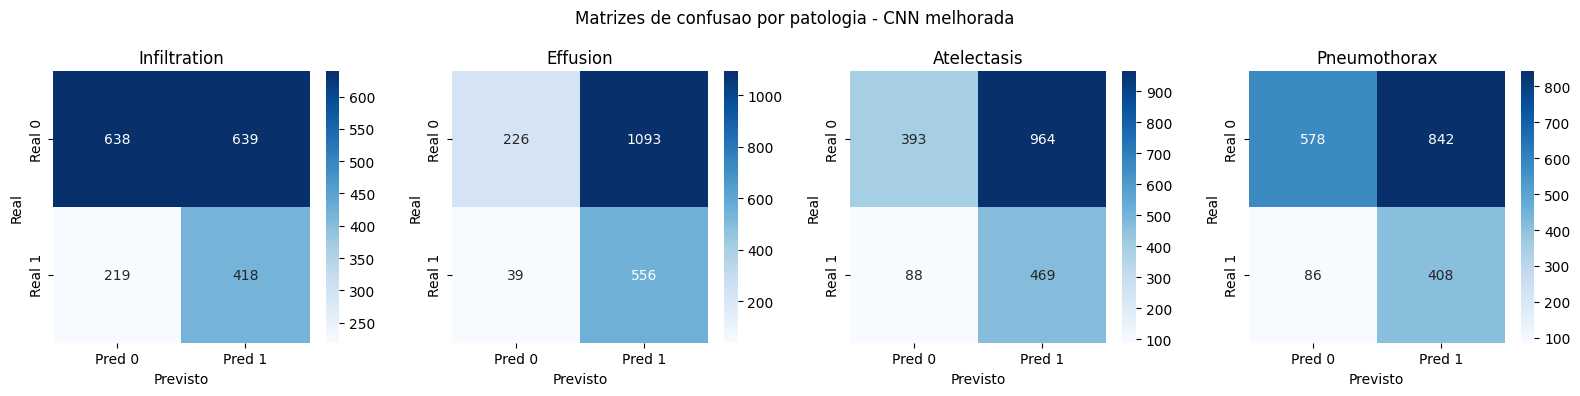

In [22]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

improved_cnn = ImprovedCNN()
if RUN_FULL_TRAINING:
    improved_cnn, history_improved = fit_model(improved_cnn, 'CNN melhorada', EPOCHS_IMPROVED, lr=5e-4)
    display(history_improved)
    evaluate_model(improved_cnn, 'CNN melhorada')

## 8. Transfer Learning - ResNet50, VGG16 e EfficientNetB0

Agora usamos modelos pre-treinados do `torchvision`. Primeiro treinamos apenas o cabecalho de classificacao; depois liberamos parte do backbone para fine-tuning leve.

C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



Treinando ResNet50


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


ResNet50 head | epoch 1/5 | loss=0.9507 | val_f1_macro=0.4560 | val_auc_macro=0.6557


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

,epoch,train_loss,accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,...,fn_total,tp_total,threshold,precision,recall,f1,specificity,roc_auc,pr_auc,stage
0,1,0.950729,0.160545,0.379295,0.392414,0.545916,0.456609,0.407988,0.562544,0.455966,...,895,1076,0.5,0.407988,0.562544,0.455966,0.658186,0.655694,0.427801,head
1,2,0.918648,0.155806,0.396475,0.395438,0.677321,0.499345,0.396233,0.682258,0.494969,...,636,1335,0.5,0.396233,0.682258,0.494969,0.574430,0.674929,0.442975,head
2,3,0.904743,0.159953,0.386700,0.399687,0.646880,0.494090,0.411561,0.664207,0.492711,...,696,1275,0.5,0.411561,0.664207,0.492711,0.606160,0.683058,0.452729,head
3,4,0.895538,0.180687,0.358264,0.422384,0.618468,0.501956,0.419380,0.620688,0.496118,...,752,1219,0.5,0.419380,0.620688,0.496118,0.651210,0.685714,0.458527,head
4,5,0.888567,0.174763,0.364633,0.420730,0.661086,0.514207,0.419168,0.656266,0.507874,...,668,1303,0.5,0.419168,0.656266,0.507874,0.620462,0.688600,0.461033,head
5,1,0.881175,0.191943,0.348934,0.432810,0.629122,0.512821,0.428488,0.628963,0.507635,...,731,1240,0.5,0.428488,0.628963,0.507635,0.657686,0.694202,0.469031,fine_tune
6,2,0.870606,0.199645,0.343898,0.437788,0.626585,0.515442,0.432659,0.625813,0.509768,...,736,1235,0.5,0.432659,0.625813,0.509768,0.665795,0.698465,0.473694,fine_tune
7,3,0.864387,0.195498,0.345972,0.436698,0.638762,0.518747,0.431832,0.639554,0.513269,...,712,1259,0.5,0.431832,0.639554,0.513269,0.658199,0.702224,0.478501,fine_tune
8,4,0.859095,0.198460,0.342565,0.440377,0.640791,0.522009,0.436010,0.642304,0.516879,...,708,1263,0.5,0.436010,0.642304,0.516879,0.662489,0.706048,0.483150,fine_tune


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


ResNet50
              precision    recall  f1-score   support

Infiltration       0.45      0.59      0.51       637
    Effusion       0.48      0.71      0.57       595
 Atelectasis       0.40      0.59      0.48       557
Pneumothorax       0.45      0.71      0.55       494

   micro avg       0.45      0.65      0.53      2283
   macro avg       0.44      0.65      0.53      2283
weighted avg       0.45      0.65      0.53      2283
 samples avg       0.35      0.51      0.39      2283



,pathology,support_positive,support_negative,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Infiltration,637,1277,0.449761,0.590267,0.510523,0.639781,0.644649,0.476773,817,460,261,376
1,Effusion,595,1319,0.475336,0.712605,0.570276,0.645186,0.732639,0.549435,851,468,171,424
2,Atelectasis,557,1357,0.403917,0.592460,0.480349,0.641120,0.660609,0.412802,870,487,227,330
3,Pneumothorax,494,1420,0.449742,0.706478,0.549606,0.699296,0.761306,0.552642,993,427,145,349


Inferencia media: 0.010177 s/imagem | Parametros: 23,516,228 | Checkpoint: 90.01 MB


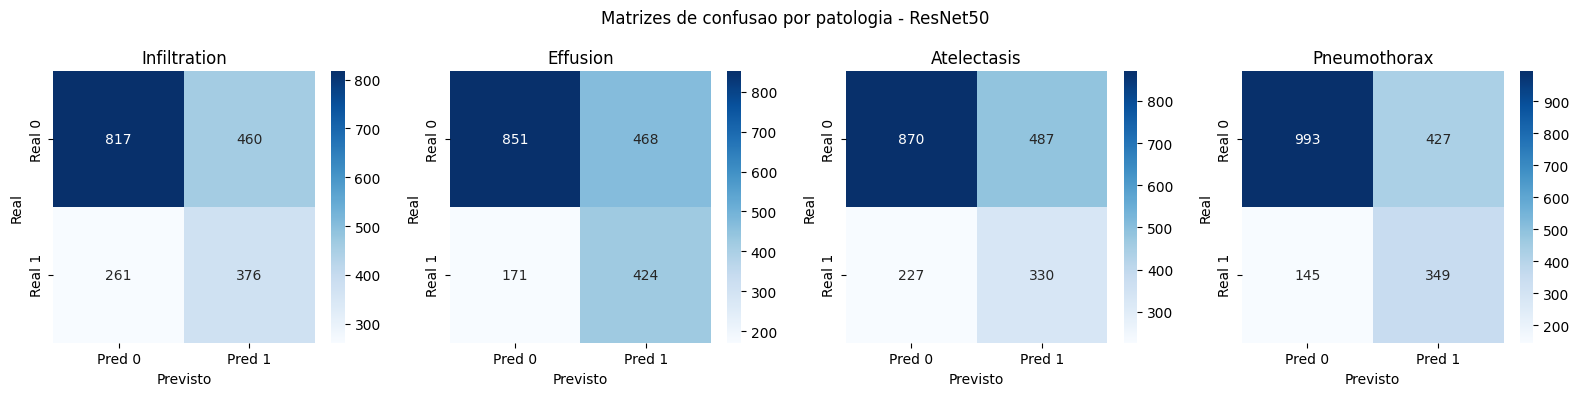


Treinando VGG16


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


VGG16 head | epoch 1/5 | loss=0.9752 | val_f1_macro=0.4198 | val_auc_macro=0.6577


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


VGG16 head | epoch 2/5 | loss=0.9526 | val_f1_macro=0.5000 | val_auc_macro=0.6764


...

,epoch,train_loss,accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,...,fn_total,tp_total,threshold,precision,recall,f1,specificity,roc_auc,pr_auc,stage
0,1,0.975233,0.132701,0.414248,0.365033,0.566717,0.444047,0.394181,0.599423,0.419833,...,854,1117,0.5,0.394181,0.599423,0.419833,0.604560,0.657695,0.427569,head
1,2,0.952607,0.158768,0.390255,0.401949,0.690512,0.508120,0.397912,0.686100,0.499979,...,610,1361,0.5,0.397912,0.686100,0.499979,0.574044,0.676416,0.447861,head
2,3,0.948442,0.165877,0.380184,0.402551,0.624556,0.489561,0.413154,0.638725,0.485984,...,740,1231,0.5,0.413154,0.638725,0.485984,0.623153,0.677903,0.448704,head
3,4,0.937463,0.197275,0.342565,0.434129,0.571791,0.493541,0.427336,0.567258,0.485771,...,844,1127,0.5,0.427336,0.567258,0.485771,0.690756,0.678651,0.456024,head
4,5,0.944311,0.165284,0.381665,0.408459,0.685946,0.512024,0.401659,0.663892,0.493939,...,619,1352,0.5,0.401659,0.663892,0.493939,0.582372,0.681655,0.453960,head
5,1,0.921008,0.177725,0.365818,0.419801,0.662608,0.513971,0.415190,0.657952,0.503977,...,665,1306,0.5,0.415190,0.657952,0.503977,0.620662,0.689585,0.467583,fine_tune
6,2,0.900283,0.184242,0.355450,0.429787,0.666159,0.522483,0.426287,0.665141,0.513269,...,658,1313,0.5,0.426287,0.665141,0.513269,0.634451,0.697774,0.478468,fine_tune
7,3,0.886865,0.197867,0.349526,0.435231,0.663115,0.525533,0.434481,0.666805,0.518822,...,664,1307,0.5,0.434481,0.666805,0.518822,0.645191,0.704742,0.490917,fine_tune
8,4,0.876871,0.199645,0.342417,0.442379,0.664130,0.531034,0.439183,0.663478,0.523236,...,662,1309,0.5,0.439183,0.663478,0.523236,0.653458,0.711602,0.500433,fine_tune


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


VGG16
              precision    recall  f1-score   support

Infiltration       0.47      0.55      0.51       637
    Effusion       0.45      0.74      0.56       595
 Atelectasis       0.40      0.74      0.52       557
Pneumothorax       0.48      0.70      0.57       494

   micro avg       0.45      0.68      0.54      2283
   macro avg       0.45      0.68      0.54      2283
weighted avg       0.45      0.68      0.54      2283
 samples avg       0.36      0.53      0.40      2283



,pathology,support_positive,support_negative,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Infiltration,637,1277,0.469960,0.552590,0.507937,0.689115,0.646305,0.506461,880,397,285,352
1,Effusion,595,1319,0.447047,0.737815,0.556753,0.588324,0.732922,0.541315,776,543,156,439
2,Atelectasis,557,1357,0.403320,0.741472,0.522454,0.549742,0.699050,0.475131,746,611,144,413
3,Pneumothorax,494,1420,0.481172,0.698381,0.569777,0.738028,0.784498,0.579683,1048,372,149,345


Inferencia media: 0.010046 s/imagem | Parametros: 134,276,932 | Checkpoint: 512.24 MB


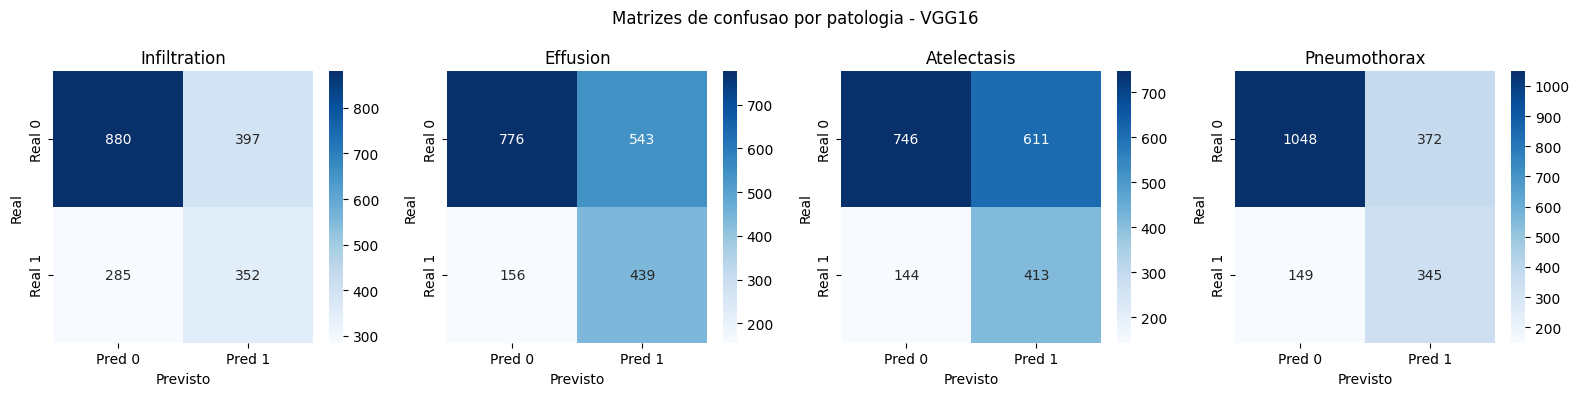

C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)



Treinando EfficientNetB0


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


EfficientNetB0 head | epoch 1/5 | loss=0.9436 | val_f1_macro=0.4881 | val_auc_macro=0.6633


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

,epoch,train_loss,accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,...,fn_total,tp_total,threshold,precision,recall,f1,specificity,roc_auc,pr_auc,stage
0,1,0.943616,0.144550,0.401659,0.390676,0.671740,0.494030,0.388497,0.672275,0.488068,...,647,1324,0.5,0.388497,0.672275,0.488068,0.567732,0.663309,0.421938,head
1,2,0.910967,0.196090,0.355450,0.426111,0.627600,0.507591,0.418195,0.616068,0.497540,...,734,1237,0.5,0.418195,0.616068,0.497540,0.646940,0.676356,0.441682,head
2,3,0.898497,0.201422,0.348045,0.432538,0.616438,0.508368,0.423559,0.603582,0.497480,...,756,1215,0.5,0.423559,0.603582,0.497480,0.661458,0.682417,0.450225,head
3,4,0.891084,0.187204,0.360338,0.424361,0.657534,0.515821,0.416481,0.640589,0.503750,...,675,1296,0.5,0.416481,0.640589,0.503750,0.625334,0.684357,0.455235,head
4,5,0.887340,0.209716,0.331902,0.447183,0.579909,0.504970,0.442292,0.580048,0.497116,...,828,1143,0.5,0.442292,0.580048,0.497116,0.703673,0.687330,0.460128,head
5,1,0.889094,0.194905,0.351748,0.432260,0.653983,0.520493,0.423060,0.637847,0.508003,...,682,1289,0.5,0.423060,0.637847,0.508003,0.640047,0.687009,0.458070,fine_tune
6,2,0.883014,0.197275,0.348045,0.434270,0.635211,0.515863,0.426105,0.622455,0.505295,...,719,1252,0.5,0.426105,0.622455,0.505295,0.653884,0.688620,0.460083,fine_tune
7,3,0.880273,0.201422,0.342861,0.438877,0.626585,0.516196,0.430739,0.615997,0.506540,...,736,1235,0.5,0.430739,0.615997,0.506540,0.665340,0.689976,0.461643,fine_tune
8,4,0.876717,0.206754,0.342713,0.439634,0.633688,0.519119,0.431769,0.623578,0.509587,...,722,1249,0.5,0.431769,0.623578,0.509587,0.662803,0.691717,0.463628,fine_tune


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


EfficientNetB0
              precision    recall  f1-score   support

Infiltration       0.43      0.59      0.50       637
    Effusion       0.45      0.70      0.55       595
 Atelectasis       0.40      0.69      0.51       557
Pneumothorax       0.46      0.63      0.53       494

   micro avg       0.43      0.65      0.52      2283
   macro avg       0.44      0.65      0.52      2283
weighted avg       0.43      0.65      0.52      2283
 samples avg       0.36      0.51      0.39      2283



,pathology,support_positive,support_negative,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Infiltration,637,1277,0.429224,0.590267,0.497026,0.608457,0.640420,0.485753,777,500,261,376
1,Effusion,595,1319,0.450980,0.695798,0.547257,0.617892,0.716374,0.514625,815,504,181,414
2,Atelectasis,557,1357,0.397331,0.694794,0.505552,0.567428,0.674768,0.443508,770,587,170,387
3,Pneumothorax,494,1420,0.463268,0.625506,0.532300,0.747887,0.753042,0.514484,1062,358,185,309


Inferencia media: 0.010070 s/imagem | Parametros: 4,012,672 | Checkpoint: 15.59 MB


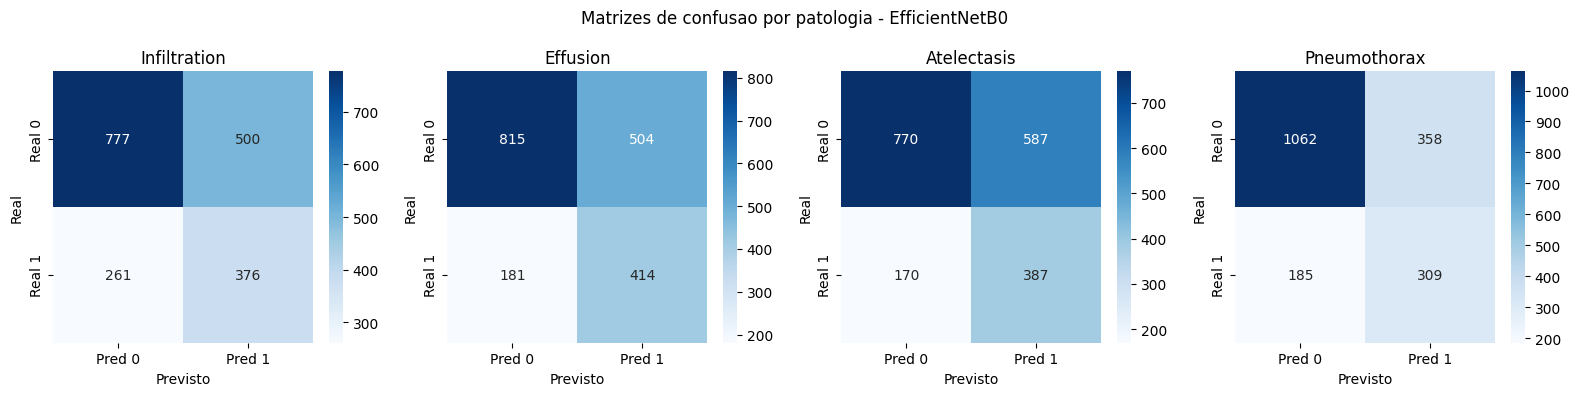

In [23]:
def set_requires_grad(module, value):
    for param in module.parameters():
        param.requires_grad = value

def build_transfer_model(name):
    if name == 'ResNet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        set_requires_grad(model, False)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
        fine_tune_modules = [model.layer4]
    elif name == 'VGG16':
        weights = models.VGG16_Weights.DEFAULT
        model = models.vgg16(weights=weights)
        set_requires_grad(model, False)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
        fine_tune_modules = [model.features[-8:]]
    elif name == 'EfficientNetB0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        set_requires_grad(model, False)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
        fine_tune_modules = [model.features[-2:]]
    else:
        raise ValueError(name)
    return model, fine_tune_modules

def train_transfer_model(name):
    model, fine_tune_modules = build_transfer_model(name)
    model, hist_head = fit_model(model, f'{name} head', EPOCHS_TRANSFER_HEAD, lr=1e-3)
    for module in fine_tune_modules:
        set_requires_grad(module, True)
    model, hist_ft = fit_model(model, name, EPOCHS_TRANSFER_FINE_TUNE, lr=1e-5, weight_decay=1e-5)
    history = pd.concat([hist_head.assign(stage='head'), hist_ft.assign(stage='fine_tune')], ignore_index=True)
    display(history)
    evaluate_model(model, name)
    return model, history

transfer_histories = {}
if RUN_FULL_TRAINING and RUN_TRANSFER_MODELS:
    for transfer_name in ['ResNet50', 'VGG16', 'EfficientNetB0']:
        print('\n' + '=' * 80)
        print('Treinando', transfer_name)
        _, transfer_histories[transfer_name] = train_transfer_model(transfer_name)

## 9. Vision Transformer

Incluimos um modelo Transformer de visao (`ViT-B/16`) via `torchvision`. Ele divide a imagem em patches e usa atencao para aprender relacoes globais.

C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Vision Transformer ViT | epoch 1/5 | loss=0.9234 | val_f1_macro=0.5069 | val_auc_macro=0.6908


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Vision Transformer ViT | epoch 2/5 | loss=0.8851 | val_f1_macro=0.5219 | val_auc_macro=0.7084


  0%|          | 0/66 [00:00<?, ?it/s]C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


...

,epoch,train_loss,accuracy,hamming_loss,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,...,fp_total,fn_total,tp_total,threshold,precision,recall,f1,specificity,roc_auc,pr_auc
0,1,0.923353,0.187796,0.355450,0.428093,0.647894,0.515543,0.421358,0.638257,0.506922,...,1706,694,1277,0.5,0.421358,0.638257,0.506922,0.637201,0.690759,0.464337
1,2,0.885118,0.232227,0.316203,0.468093,0.610350,0.529839,0.460450,0.605911,0.521915,...,1367,768,1203,0.5,0.460450,0.605911,0.521915,0.711235,0.708408,0.490893
2,3,0.867719,0.210308,0.328643,0.456522,0.660578,0.539913,0.450868,0.641084,0.526561,...,1550,669,1302,0.5,0.450868,0.641084,0.526561,0.667140,0.715378,0.501088
3,4,0.862341,0.180687,0.350415,0.437122,0.696601,0.537167,0.432400,0.675869,0.525739,...,1768,598,1373,0.5,0.432400,0.675869,0.525739,0.618792,0.720495,0.506216
4,5,0.854020,0.213863,0.323312,0.461370,0.642314,0.537010,0.463755,0.646276,0.534985,...,1478,705,1266,0.5,0.463755,0.646276,0.534985,0.689231,0.723964,0.511617


C:\Users\felip\AppData\Local\Temp\ipykernel_19500\2610406426.py:184: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Vision Transformer ViT
              precision    recall  f1-score   support

Infiltration       0.46      0.57      0.51       637
    Effusion       0.53      0.65      0.58       595
 Atelectasis       0.40      0.71      0.51       557
Pneumothorax       0.47      0.71      0.57       494

   micro avg       0.46      0.66      0.54      2283
   macro avg       0.47      0.66      0.54      2283
weighted avg       0.47      0.66      0.54      2283
 samples avg       0.39      0.52      0.41      2283



,pathology,support_positive,support_negative,precision,recall,f1,specificity,roc_auc,pr_auc,tn,fp,fn,tp
0,Infiltration,637,1277,0.460277,0.572998,0.510490,0.664839,0.649613,0.508912,849,428,272,365
1,Effusion,595,1319,0.533333,0.645378,0.584030,0.745262,0.757819,0.577353,983,336,211,384
2,Atelectasis,557,1357,0.397384,0.709156,0.509349,0.558585,0.685708,0.458376,758,599,162,395
3,Pneumothorax,494,1420,0.469415,0.714575,0.566613,0.719014,0.787184,0.584365,1021,399,141,353


Inferencia media: 0.010037 s/imagem | Parametros: 85,801,732 | Checkpoint: 327.37 MB


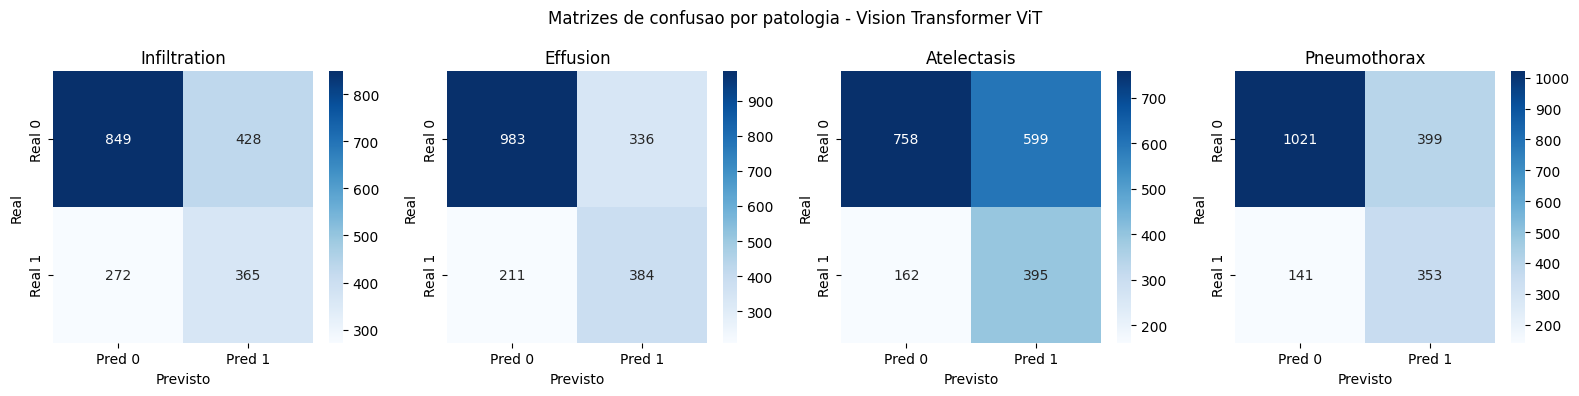

In [24]:
def build_vit_model():
    weights = models.ViT_B_16_Weights.DEFAULT
    model = models.vit_b_16(weights=weights)
    set_requires_grad(model, False)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, NUM_CLASSES)
    return model

if RUN_FULL_TRAINING and RUN_VISION_TRANSFORMER:
    vit_model = build_vit_model()
    vit_model, history_vit = fit_model(vit_model, 'Vision Transformer ViT', EPOCHS_VIT, lr=1e-3)
    display(history_vit)
    evaluate_model(vit_model, 'Vision Transformer ViT')

## 10. Comparativo entre modelos

A escolha final combina desempenho multi-label e eficiencia operacional. O ranking ponderado usa 40% F1 macro, 30% recall macro, 20% AUC-ROC macro e 10% tempo medio de inferencia por imagem.

Na execucao completa, o `Vision Transformer ViT` ficou em primeiro lugar, com F1 macro `0.5426`, recall macro `0.6605`, AUC-ROC macro `0.7201`, PR-AUC macro `0.5323` e `0.0100` segundo por imagem. O `VGG16` ficou praticamente empatado e ate teve recall macro maior (`0.6826`), mas perdeu por pequena diferenca no F1 macro, AUC-ROC macro e score final. A `CNN melhorada` atingiu o maior recall macro (`0.8146`), porem gerou muitos falsos positivos e baixa especificidade macro (`0.3419`), o que mostra o trade-off entre detectar mais casos positivos e manter confianca operacional.

A acuracia deve ser lida com cautela: no contexto multi-label ela e uma acuracia de conjunto exato, ou seja, so conta acerto quando todas as quatro labels da imagem coincidem com o gabarito. Por isso, hamming loss, F1 macro/micro, recall por classe, AUC-ROC, PR-AUC e matriz de confusao por patologia sao mais informativos para a avaliacao deste problema.


,model_name,accuracy,hamming_loss,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,specificity_macro,roc_auc_macro,pr_auc_macro,seconds_per_image,total_parameters,trainable_parameters,checkpoint_size_bytes,f1_rank,recall_rank,auc_roc_rank,inference_rank,selection_score,tn_total,fp_total,fn_total,tp_total,checkpoint_path
5,Vision Transformer ViT,0.212,0.333,0.465,0.661,0.543,0.459,0.656,0.540,0.672,0.720,0.532,0.010037,85801732,3076,343270097,1.000000,4.000000,1.000000,1.000000,1.900,3611,1762,786,1497,artifacts_cardioia_pytorch_multilabel\modelos\vision_transformer_vit.pt
3,VGG16,0.195,0.347,0.450,0.683,0.539,0.446,0.678,0.538,0.641,0.716,0.526,0.010046,134276932,7095812,537117623,2.000000,2.000000,2.000000,2.000000,2.000,3450,1923,734,1549,artifacts_cardioia_pytorch_multilabel\modelos\vgg16.pt
2,ResNet50,0.194,0.346,0.445,0.650,0.528,0.445,0.648,0.528,0.656,0.700,0.498,0.010177,23516228,14972932,94383237,3.000000,6.000000,3.000000,4.000000,4.000,3531,1842,804,1479,artifacts_cardioia_pytorch_multilabel\modelos\resnet50.pt
4,EfficientNetB0,0.180,0.359,0.435,0.652,0.521,0.433,0.651,0.520,0.635,0.696,0.490,0.010070,4012672,1134516,16351665,4.000000,5.000000,4.000000,3.000000,4.200,3424,1949,797,1486,artifacts_cardioia_pytorch_multilabel\modelos\efficientnetb0.pt
1,CNN melhorada,0.068,0.519,0.347,0.815,0.482,0.343,0.811,0.483,0.342,0.648,0.429,0.010216,1206628,1206628,4852643,6.000000,1.000000,6.000000,5.000000,4.400,1835,3538,432,1851,artifacts_cardioia_pytorch_multilabel\modelos\cnn_melhorada.pt
0,CNN base,0.124,0.415,0.389,0.682,0.494,0.389,0.687,0.497,0.538,0.667,0.445,0.011012,12938948,12938948,51760341,5.000000,3.000000,5.000000,6.000000,4.500,2909,2464,715,1568,artifacts_cardioia_pytorch_multilabel\modelos\cnn_base.pt


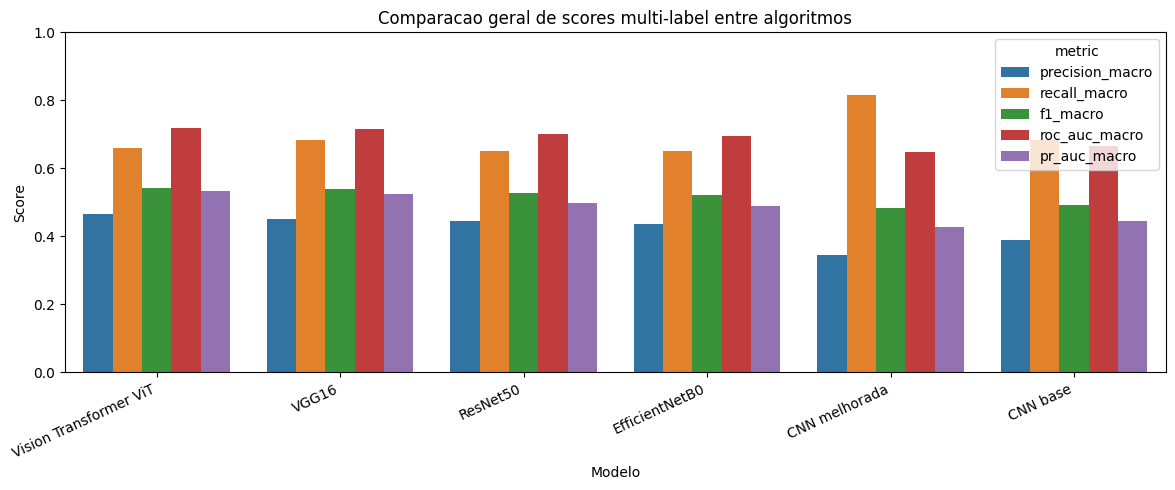

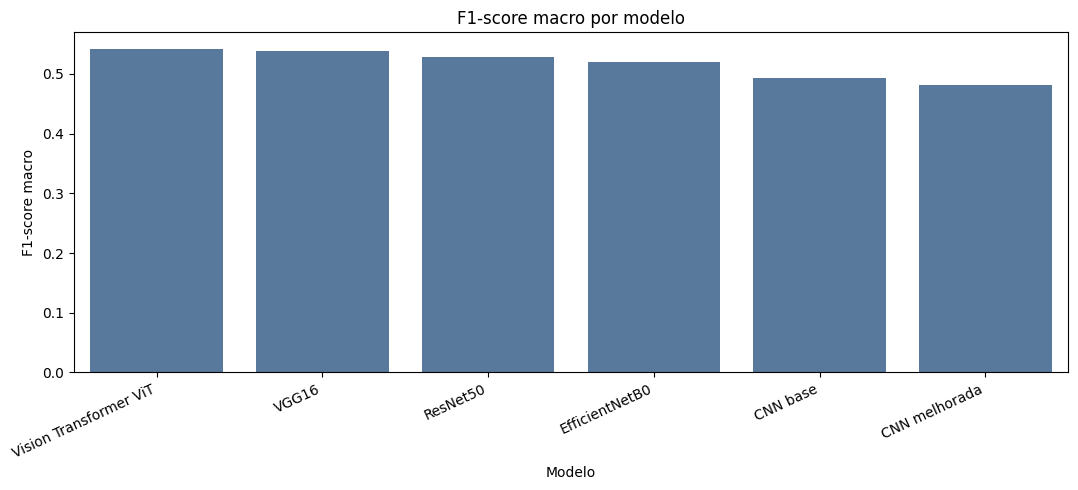

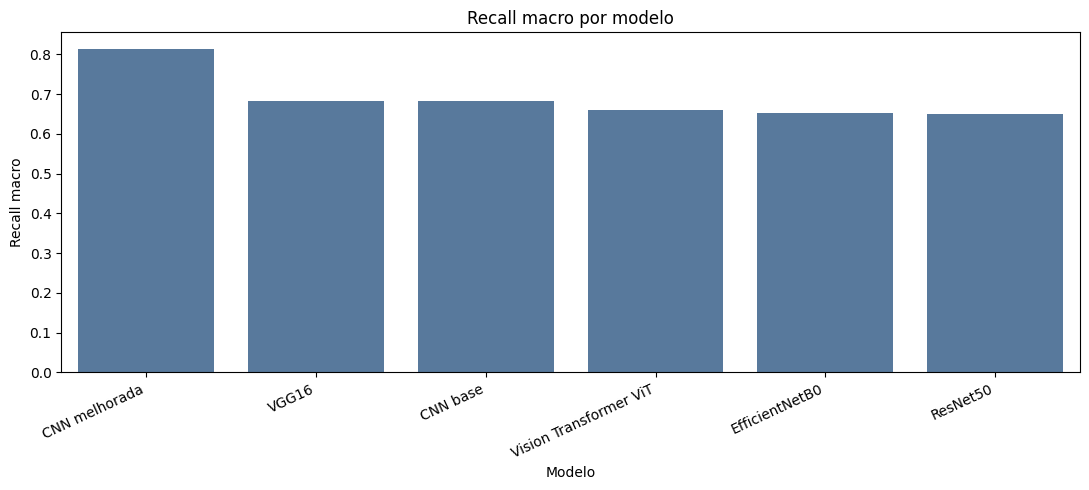

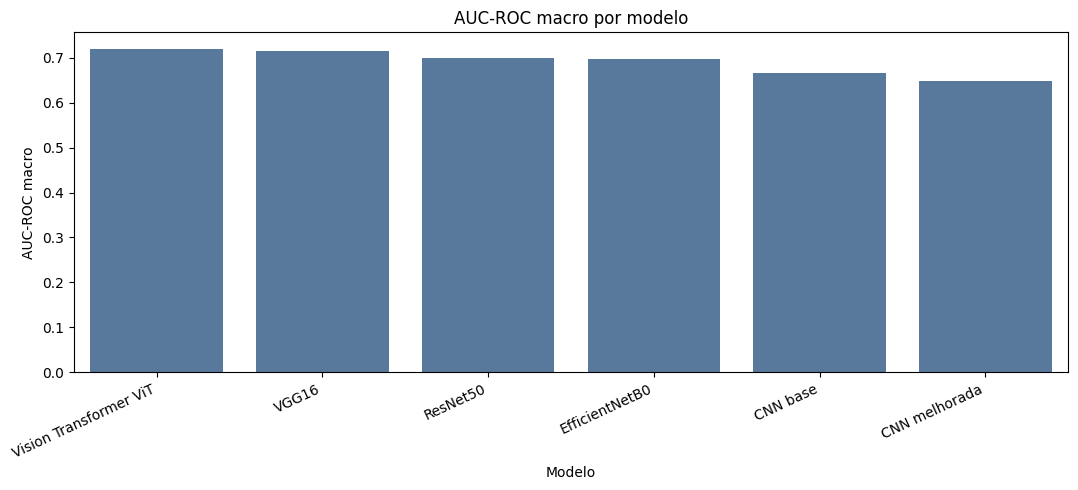

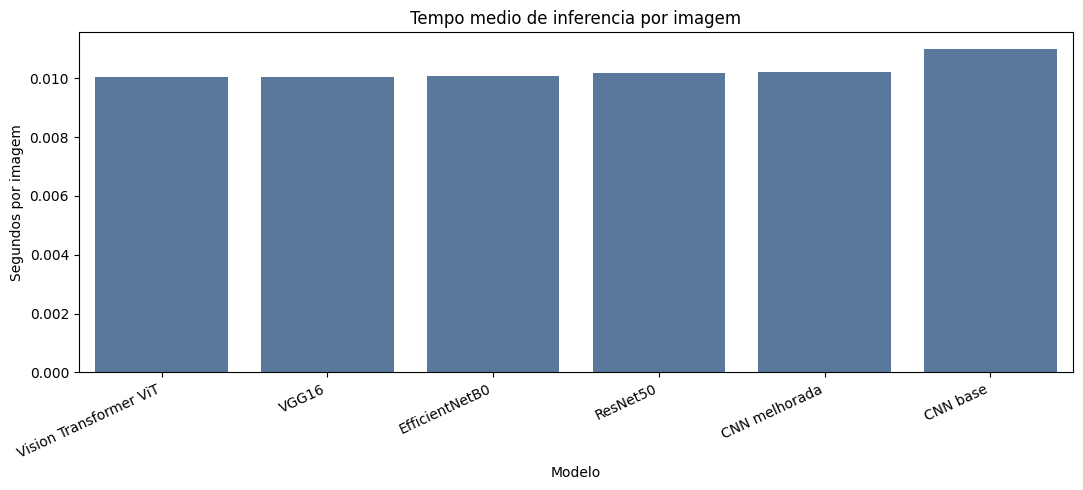

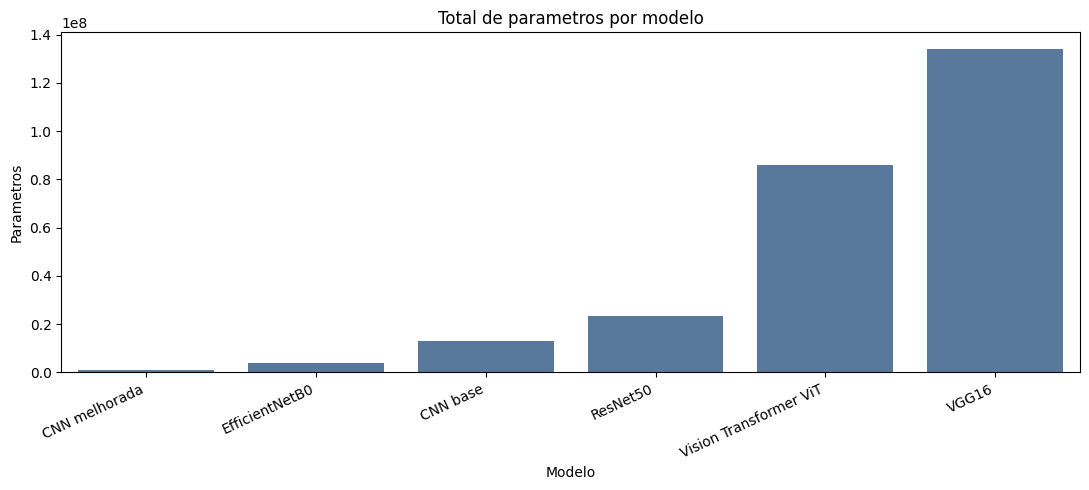

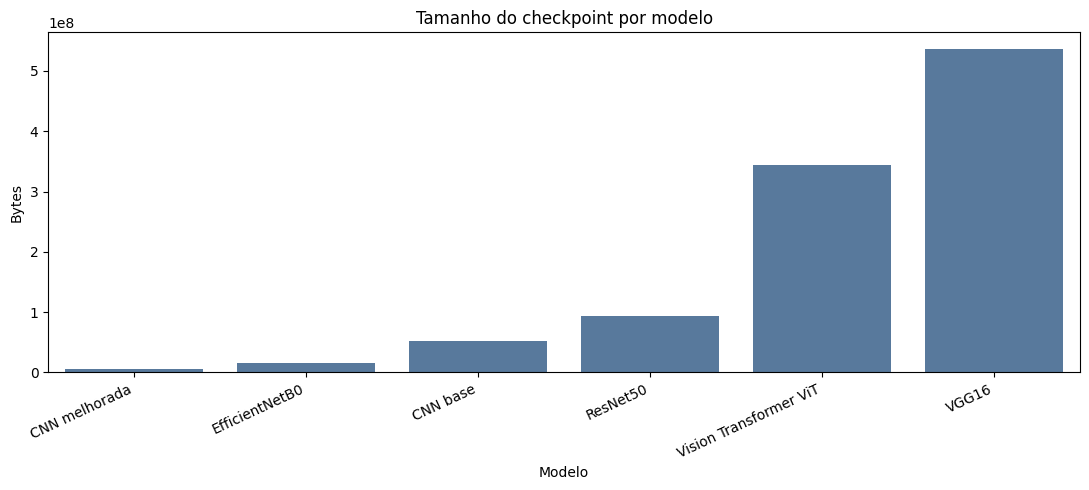

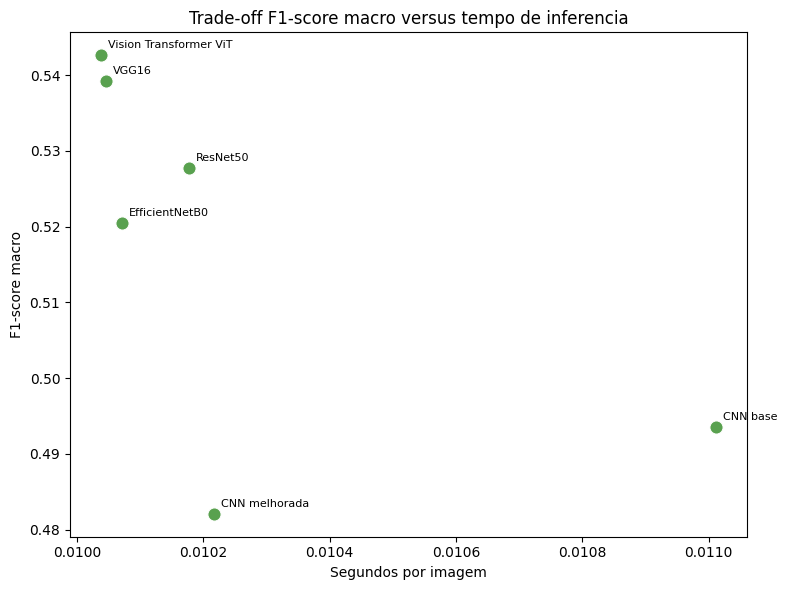

Modelo final selecionado: Vision Transformer ViT
Criterio: menor selection_score em ranking ponderado com 40% F1 macro, 30% recall macro, 20% AUC-ROC macro e 10% tempo de inferencia.
Resultados no teste: F1 macro=0.5426, recall macro=0.6605, AUC-ROC macro=0.7201, precision macro=0.4651, tempo=0.010037 s/imagem.
A decisao prioriza deteccao multi-label das patologias selecionadas sem ignorar custo operacional, matrizes de confusao por classe, ajuste de threshold e fairness.


In [25]:
def add_selection_scores(metrics_df):
    ranked = metrics_df.copy()
    if 'auc_roc' not in ranked.columns and 'roc_auc_macro' in ranked.columns:
        ranked['auc_roc'] = ranked['roc_auc_macro']
    if 'model_name' not in ranked.columns:
        ranked['model_name'] = ranked['model']

    ranked['f1_rank'] = ranked['f1_macro'].rank(ascending=False, method='min')
    ranked['recall_rank'] = ranked['recall_macro'].rank(ascending=False, method='min')
    ranked['auc_roc_rank'] = ranked['auc_roc'].rank(ascending=False, method='min')

    if 'seconds_per_image' in ranked.columns and ranked['seconds_per_image'].notna().any():
        ranked['inference_rank'] = ranked['seconds_per_image'].rank(ascending=True, method='min')
    else:
        ranked['seconds_per_image'] = np.nan
        ranked['inference_rank'] = len(ranked)

    ranked['selection_score'] = (
        0.4 * ranked['f1_rank']
        + 0.3 * ranked['recall_rank']
        + 0.2 * ranked['auc_roc_rank']
        + 0.1 * ranked['inference_rank']
    )
    return ranked.sort_values(['selection_score', 'f1_macro', 'recall_macro', 'auc_roc'], ascending=[True, False, False, False])

def plot_metric_bar(data, metric, title, output_name, ascending=False, ylabel=None):
    if data.empty or metric not in data.columns:
        print(f'Grafico ignorado: {metric} indisponivel.')
        return
    plot_data = data.dropna(subset=[metric]).sort_values(metric, ascending=ascending)
    if plot_data.empty:
        print(f'Grafico ignorado: {metric} sem valores validos.')
        return
    plt.figure(figsize=(11, 5))
    sns.barplot(data=plot_data, x='model_name', y=metric, color='#4C78A8')
    plt.xticks(rotation=25, ha='right')
    plt.xlabel('Modelo')
    plt.ylabel(ylabel or metric)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / output_name, dpi=160, bbox_inches='tight')
    plt.show()

def plot_tradeoff(data):
    required_cols = {'seconds_per_image', 'f1_macro', 'model_name'}
    if data.empty or not required_cols.issubset(data.columns):
        print('Grafico de trade-off indisponivel.')
        return
    plot_data = data.dropna(subset=['seconds_per_image', 'f1_macro'])
    if plot_data.empty:
        print('Grafico de trade-off sem valores validos.')
        return
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=plot_data, x='seconds_per_image', y='f1_macro', s=90, color='#59A14F')
    for _, row in plot_data.iterrows():
        plt.annotate(row['model_name'], (row['seconds_per_image'], row['f1_macro']), fontsize=8, xytext=(5, 5), textcoords='offset points')
    plt.xlabel('Segundos por imagem')
    plt.ylabel('F1-score macro')
    plt.title('Trade-off F1-score macro versus tempo de inferencia')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'comparacao_f1_macro_vs_inferencia.png', dpi=160, bbox_inches='tight')
    plt.show()

if experiment_results:
    all_metrics_df = pd.DataFrame(experiment_results)
    if 'auc_roc' not in all_metrics_df.columns and 'roc_auc_macro' in all_metrics_df.columns:
        all_metrics_df['auc_roc'] = all_metrics_df['roc_auc_macro']
    if 'model_name' not in all_metrics_df.columns:
        all_metrics_df['model_name'] = all_metrics_df['model']

    for optional_col in ['seconds_per_image', 'total_parameters', 'trainable_parameters', 'checkpoint_size_bytes', 'checkpoint_path']:
        if optional_col not in all_metrics_df.columns:
            all_metrics_df[optional_col] = np.nan

    ranked_metrics = add_selection_scores(all_metrics_df)
    score_cols = [
        'model_name', 'accuracy', 'hamming_loss', 'precision_macro', 'recall_macro', 'f1_macro',
        'precision_micro', 'recall_micro', 'f1_micro', 'specificity_macro', 'roc_auc_macro', 'pr_auc_macro',
        'seconds_per_image', 'total_parameters', 'trainable_parameters', 'checkpoint_size_bytes',
        'f1_rank', 'recall_rank', 'auc_roc_rank', 'inference_rank', 'selection_score',
        'tn_total', 'fp_total', 'fn_total', 'tp_total', 'checkpoint_path',
    ]
    available_cols = [column for column in score_cols if column in ranked_metrics.columns]

    all_metrics_df.to_csv(TABLES_DIR / 'model_comparison_all_metrics.csv', index=False)
    ranked_metrics.to_csv(TABLES_DIR / 'model_comparison_ranked.csv', index=False)
    ranked_metrics.to_csv(ARTIFACT_DIR / 'comparativo_modelos.csv', index=False)

    format_cols = {column: '{:.3f}' for column in ['accuracy', 'hamming_loss', 'precision_macro', 'recall_macro', 'f1_macro', 'precision_micro', 'recall_micro', 'f1_micro', 'specificity_macro', 'roc_auc_macro', 'pr_auc_macro', 'selection_score'] if column in ranked_metrics.columns}
    if 'seconds_per_image' in ranked_metrics.columns:
        format_cols['seconds_per_image'] = '{:.6f}'
    display(ranked_metrics[available_cols].style.format(format_cols))

    performance_plot_df = ranked_metrics.melt(
        id_vars='model_name',
        value_vars=[metric for metric in ['precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_macro', 'pr_auc_macro'] if metric in ranked_metrics.columns],
        var_name='metric',
        value_name='score',
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=performance_plot_df, x='model_name', y='score', hue='metric')
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha='right')
    plt.xlabel('Modelo')
    plt.ylabel('Score')
    plt.title('Comparacao geral de scores multi-label entre algoritmos')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'comparacao_scores_geral.png', dpi=160, bbox_inches='tight')
    plt.show()

    plot_metric_bar(ranked_metrics, 'f1_macro', 'F1-score macro por modelo', 'comparacao_f1_macro_por_modelo.png', ascending=False, ylabel='F1-score macro')
    plot_metric_bar(ranked_metrics, 'recall_macro', 'Recall macro por modelo', 'comparacao_recall_macro_por_modelo.png', ascending=False, ylabel='Recall macro')
    plot_metric_bar(ranked_metrics, 'roc_auc_macro', 'AUC-ROC macro por modelo', 'comparacao_auc_macro_por_modelo.png', ascending=False, ylabel='AUC-ROC macro')
    plot_metric_bar(ranked_metrics, 'seconds_per_image', 'Tempo medio de inferencia por imagem', 'comparacao_inferencia_por_modelo.png', ascending=True, ylabel='Segundos por imagem')
    plot_metric_bar(ranked_metrics, 'total_parameters', 'Total de parametros por modelo', 'comparacao_parametros_por_modelo.png', ascending=True, ylabel='Parametros')
    plot_metric_bar(ranked_metrics, 'checkpoint_size_bytes', 'Tamanho do checkpoint por modelo', 'comparacao_tamanho_checkpoint_por_modelo.png', ascending=True, ylabel='Bytes')
    plot_tradeoff(ranked_metrics)

    best_model_name = ranked_metrics.iloc[0]['model']
    final_selection = ranked_metrics.iloc[[0]][available_cols]
    final_selection.to_csv(TABLES_DIR / 'final_model_selection.csv', index=False)

    final_row = ranked_metrics.iloc[0]
    inference_text = 'nao recalculado nesta execucao' if pd.isna(final_row['seconds_per_image']) else f"{final_row['seconds_per_image']:.6f} s/imagem"
    justification = (
        f"Modelo final selecionado: {final_row['model_name']}\n"
        f"Criterio: menor selection_score em ranking ponderado com 40% F1 macro, 30% recall macro, 20% AUC-ROC macro e 10% tempo de inferencia.\n"
        f"Resultados no teste: F1 macro={final_row['f1_macro']:.4f}, recall macro={final_row['recall_macro']:.4f}, "
        f"AUC-ROC macro={final_row['roc_auc_macro']:.4f}, precision macro={final_row['precision_macro']:.4f}, tempo={inference_text}.\n"
        "A decisao prioriza deteccao multi-label das patologias selecionadas sem ignorar custo operacional, matrizes de confusao por classe, ajuste de threshold e fairness."
    )
    (ARTIFACT_DIR / 'justificativa_modelo_final.txt').write_text(justification, encoding='utf-8')
    print(justification)
else:
    ranked_metrics = pd.DataFrame()
    print('Nenhum modelo treinado ainda.')


## 11. Ajuste de threshold

O threshold padrao e 0.5. Em classificacao multi-label, esse threshold e aplicado independentemente a cada patologia. A varredura abaixo avalia um threshold global.


,threshold,precision_macro,recall_macro,f1_macro,roc_auc_macro,pr_auc_macro,hamming_loss
9,0.50,0.465102,0.660527,0.542620,0.720081,0.532252,0.332811
8,0.45,0.426410,0.747630,0.540814,0.720081,0.532252,0.380225
7,0.40,0.391990,0.822677,0.529121,0.720081,0.532252,0.440178
10,0.55,0.497533,0.565047,0.525582,0.720081,0.532252,0.303161
6,0.35,0.366316,0.895236,0.518152,0.720081,0.532252,0.500914
5,0.30,0.347574,0.943589,0.506598,0.720081,0.532252,0.551202
4,0.25,0.330710,0.971026,0.492272,0.720081,0.532252,0.598485
11,0.60,0.535739,0.462527,0.491869,0.720081,0.532252,0.283046
3,0.20,0.317271,0.985018,0.479109,0.720081,0.532252,0.638454
2,0.15,0.307295,0.994920,0.468841,0.720081,0.532252,0.670846


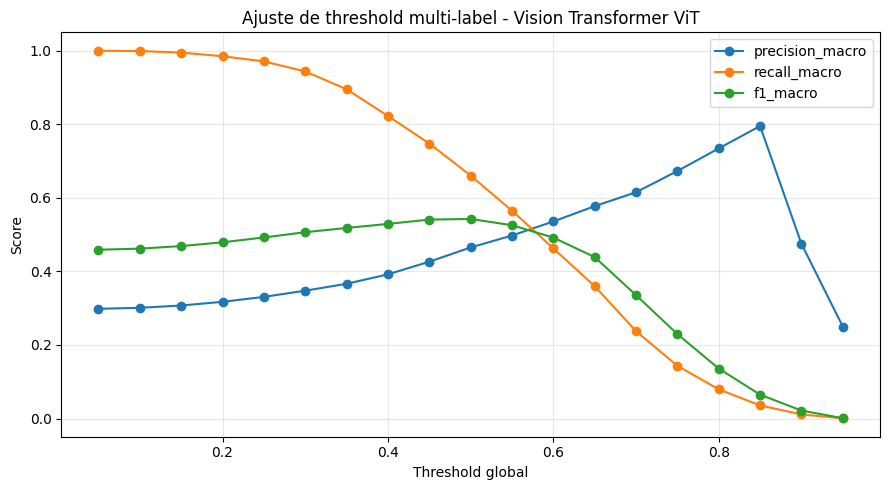

In [26]:
def threshold_sweep(y_true, y_proba):
    rows = []
    for threshold in np.linspace(0.05, 0.95, 19):
        row = compute_metrics(y_true, y_proba, threshold=float(threshold))
        rows.append(row)
    return pd.DataFrame(rows)

if experiment_results:
    best_preds = predictions_registry[best_model_name]
    y_true = best_preds[[f'true_{label.lower()}' for label in SELECTED_PATHOLOGIES]].values
    y_proba = best_preds[[f'proba_{label.lower()}' for label in SELECTED_PATHOLOGIES]].values
    sweep_df = threshold_sweep(y_true, y_proba)
    display(sweep_df[['threshold', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_macro', 'pr_auc_macro', 'hamming_loss']].sort_values('f1_macro', ascending=False).head(10))

    plt.figure(figsize=(9, 5))
    for metric in ['precision_macro', 'recall_macro', 'f1_macro']:
        plt.plot(sweep_df['threshold'], sweep_df[metric], marker='o', label=metric)
    plt.xlabel('Threshold global')
    plt.ylabel('Score')
    plt.title(f'Ajuste de threshold multi-label - {best_model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'threshold_sweep_multilabel.png', dpi=160, bbox_inches='tight')
    plt.show()


## 12. Fairness e governanca

Avaliamos representatividade e desempenho por subgrupo. Como o problema agora e multi-label, a fairness e calculada para qualquer patologia selecionada e tambem por patologia individual.

A leitura de fairness deve ser feita como auditoria de risco, nao como prova clinica definitiva. Os maiores gaps apareceram principalmente por `View Position` e por faixa etaria. Em idade, alguns subgrupos sao pequenos, especialmente `81+` no teste, com apenas 12 imagens, entao os gaps podem ser instaveis. Mesmo assim, eles indicam pontos que deveriam ser monitorados antes de qualquer uso real: diferencas de recall, taxa de falso positivo e F1 por subgrupo podem gerar impactos distintos em triagem medica.


,target,group_col,group,n,positives,predicted_positives,sample_share,base_rate_true_positive,selection_rate_predicted_positive,low_sample_warning
0,any_selected_pathology,Patient Gender,M,1019,806,836,0.532393,0.790972,0.820412,False
1,any_selected_pathology,Patient Gender,F,895,734,761,0.467607,0.820112,0.850279,False
2,any_selected_pathology,age_group,41-60,794,642,647,0.414838,0.808564,0.814861,False
3,any_selected_pathology,age_group,19-40,544,428,442,0.284222,0.786765,0.812500,False
4,any_selected_pathology,age_group,61-80,453,367,397,0.236677,0.810155,0.876380,False
5,any_selected_pathology,age_group,0-18,111,94,101,0.057994,0.846847,0.909910,False
6,any_selected_pathology,age_group,81+,12,9,10,0.006270,0.750000,0.833333,False
7,any_selected_pathology,View Position,PA,1103,854,841,0.576280,0.774252,0.762466,False
8,any_selected_pathology,View Position,AP,811,686,756,0.423720,0.845869,0.932182,False
9,Infiltration,Patient Gender,M,1019,339,427,0.532393,0.332679,0.419038,False


,target,group_col,group,n,skipped_low_sample,base_rate_true_positive,selection_rate_predicted_positive,accuracy,precision,recall_equal_opportunity,f1,roc_auc,specificity,false_positive_rate,false_negative_rate,tn,fp,fn,tp
0,any_selected_pathology,Patient Gender,F,895,False,0.820112,0.850279,0.813408,0.872536,0.904632,0.888294,0.779774,0.397516,0.602484,0.095368,64,97,70,664
1,any_selected_pathology,Patient Gender,M,1019,False,0.790972,0.820412,0.778214,0.846890,0.878412,0.862363,0.724365,0.399061,0.600939,0.121588,85,128,98,708
2,any_selected_pathology,age_group,0-18,111,False,0.846847,0.909910,0.846847,0.881188,0.946809,0.912821,0.789737,0.294118,0.705882,0.053191,5,12,5,89
3,any_selected_pathology,age_group,19-40,544,False,0.786765,0.812500,0.786765,0.852941,0.880841,0.866667,0.768430,0.439655,0.560345,0.119159,51,65,51,377
4,any_selected_pathology,age_group,41-60,794,False,0.808564,0.814861,0.789673,0.867079,0.873832,0.870442,0.756487,0.434211,0.565789,0.126168,66,86,81,561
5,any_selected_pathology,age_group,61-80,453,False,0.810155,0.876380,0.801325,0.848866,0.918256,0.882199,0.700938,0.302326,0.697674,0.081744,26,60,30,337
6,any_selected_pathology,age_group,81+,12,False,0.750000,0.833333,0.750000,0.800000,0.888889,0.842105,0.888889,0.333333,0.666667,0.111111,1,2,1,8
7,any_selected_pathology,View Position,AP,811,False,0.845869,0.932182,0.849568,0.873016,0.962099,0.915395,0.702029,0.232000,0.768000,0.037901,29,96,26,660
8,any_selected_pathology,View Position,PA,1103,False,0.774252,0.762466,0.754306,0.846611,0.833724,0.840118,0.759422,0.481928,0.518072,0.166276,120,129,142,712
9,Infiltration,Patient Gender,F,895,False,0.332961,0.408939,0.642458,0.469945,0.577181,0.518072,0.661153,0.675042,0.324958,0.422819,403,194,126,172


,target,group_col,min_group_n,max_group_n,demographic_parity_gap,demographic_parity_gap_worst_group,demographic_parity_gap_best_group,equal_opportunity_recall_gap,equal_opportunity_recall_gap_worst_group,equal_opportunity_recall_gap_best_group,...,fpr_gap_best_group,fnr_gap,fnr_gap_worst_group,fnr_gap_best_group,precision_gap,precision_gap_worst_group,precision_gap_best_group,f1_gap,f1_gap_worst_group,f1_gap_best_group
0,Atelectasis,Patient Gender,895,1019,0.077234,F,M,0.050751,F,M,...,M,0.050751,M,F,0.003773,M,F,0.010080,F,M
1,Atelectasis,View Position,811,1103,0.149396,PA,AP,0.108503,PA,AP,...,AP,0.108503,AP,PA,0.031732,PA,AP,0.054018,PA,AP
2,Atelectasis,age_group,12,794,0.319551,0-18,61-80,0.470588,81+,61-80,...,81+,0.470588,61-80,81+,0.290709,81+,41-60,0.347059,81+,41-60
3,Effusion,Patient Gender,895,1019,0.025862,M,F,0.087655,M,F,...,M,0.087655,F,M,0.049305,M,F,0.065435,M,F
4,Effusion,View Position,811,1103,0.277989,PA,AP,0.135129,PA,AP,...,AP,0.135129,AP,PA,0.098730,AP,PA,0.001329,AP,PA
5,Effusion,age_group,12,794,0.109658,41-60,61-80,0.150000,0-18,81+,...,61-80,0.150000,81+,0-18,0.242857,0-18,81+,0.218905,0-18,81+
6,Infiltration,Patient Gender,895,1019,0.010100,F,M,0.007860,M,F,...,M,0.007860,F,M,0.017955,M,F,0.014156,M,F
7,Infiltration,View Position,811,1103,0.545593,PA,AP,0.619340,PA,AP,...,AP,0.619340,AP,PA,0.139334,PA,AP,0.340854,PA,AP
8,Infiltration,age_group,12,794,0.177627,41-60,0-18,0.511905,41-60,81+,...,0-18,0.511905,81+,41-60,0.362278,41-60,81+,0.427350,41-60,81+
9,Pneumothorax,Patient Gender,895,1019,0.149760,M,F,0.153319,M,F,...,F,0.153319,F,M,0.002364,M,F,0.050225,M,F


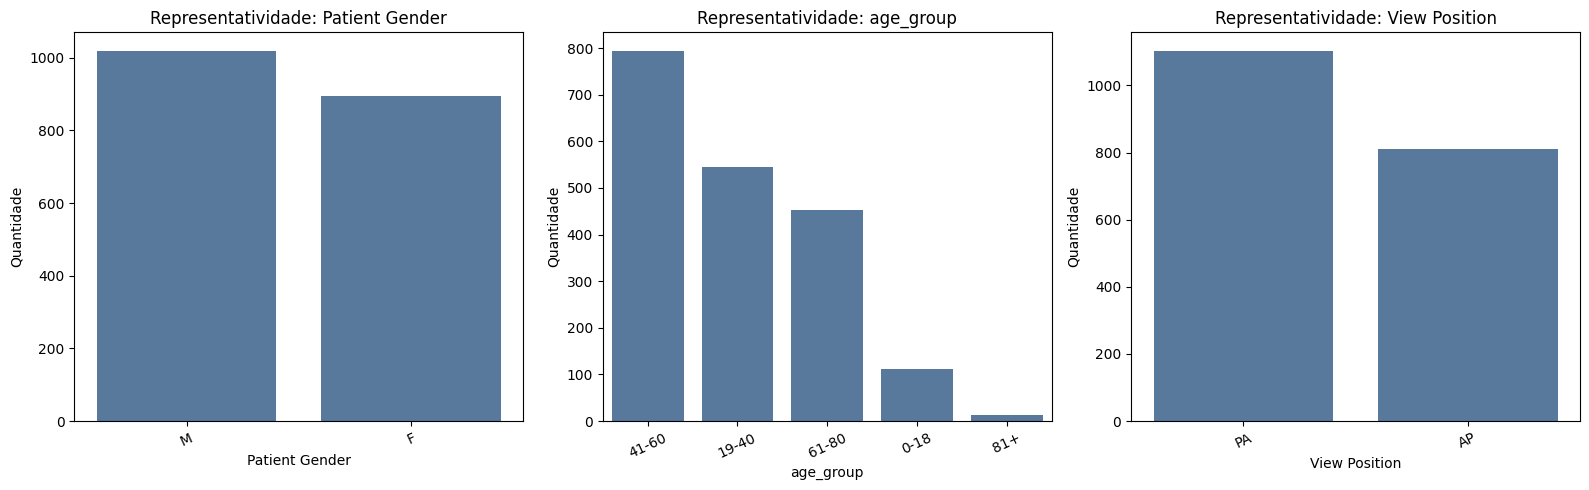

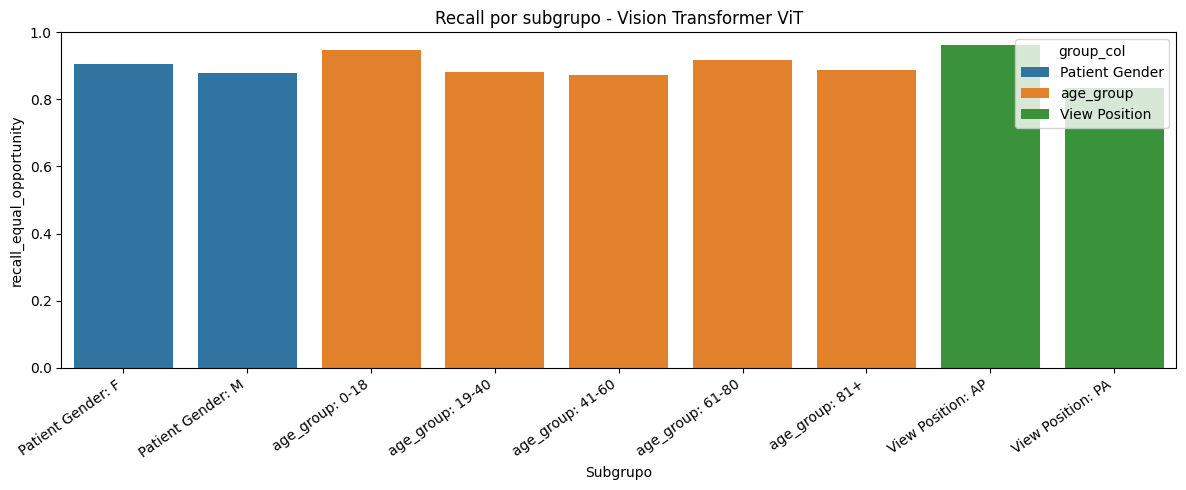

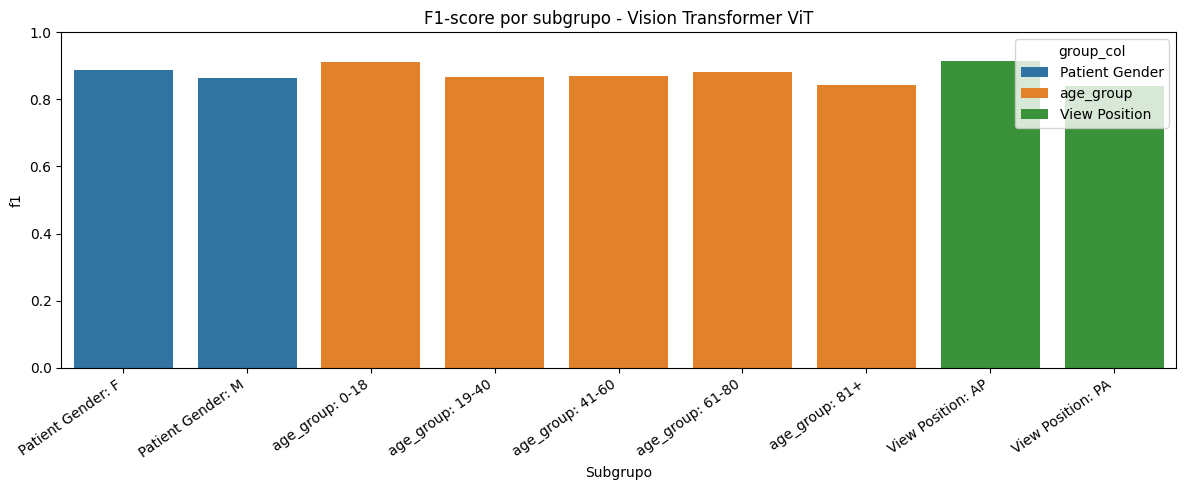

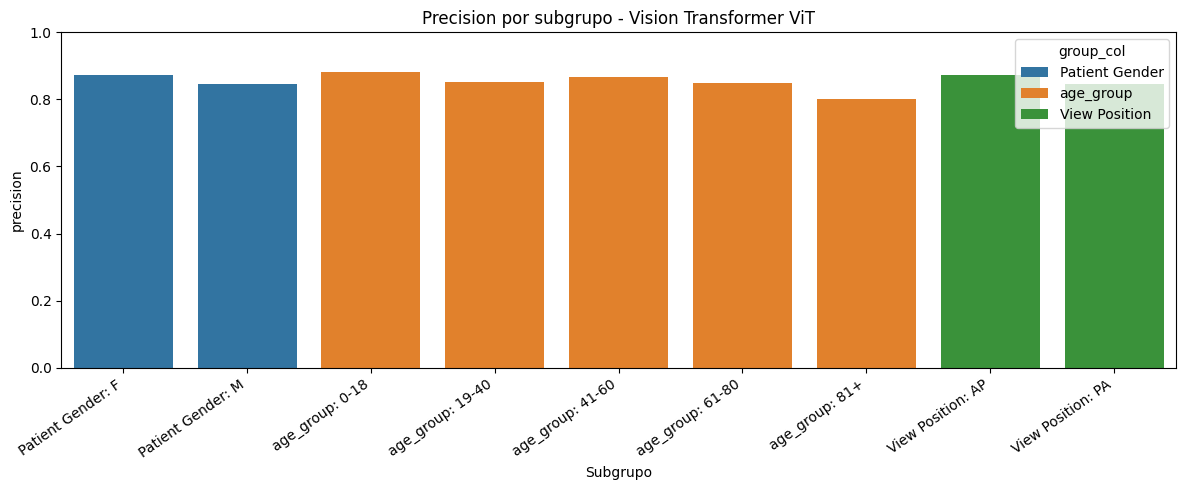

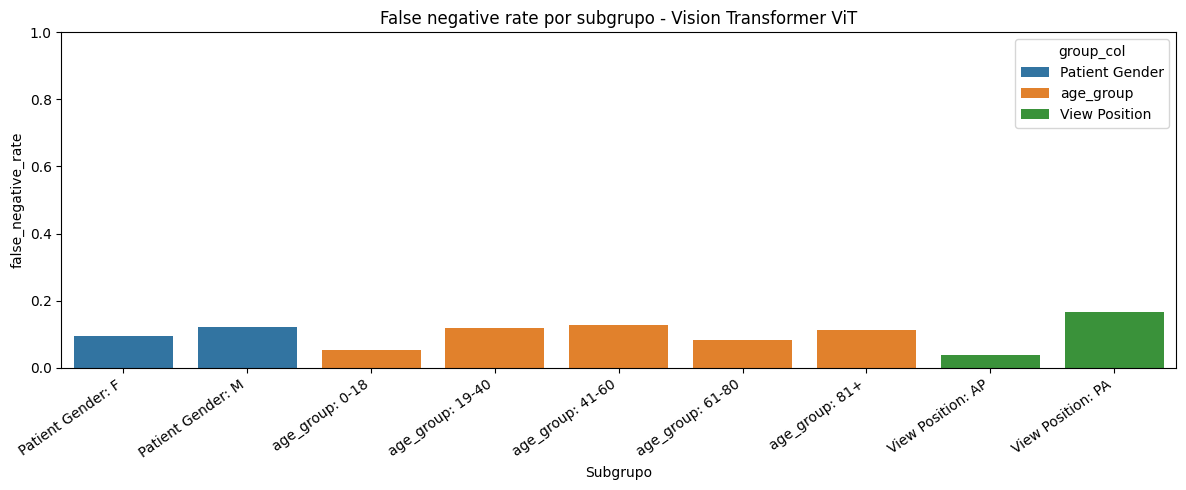

# Governanca, Fairness e Limitacoes

A analise foi realizada no conjunto de teste para o modelo final `Vision Transformer ViT`. Foram avaliados genero, faixa etaria e posicao da imagem para qualquer patologia selecionada e para cada patologia individual.

## Representatividade

Subgrupos com menos de 10 amostras foram marcados com `skipped_low_sample`, pois metricas com poucas observacoes podem oscilar muito e nao devem sustentar conclusoes fortes.

## Metricas por subgrupo

Foram calculadas accuracy, precision, recall, F1-score, AUC-ROC, specificity, false positive rate e false negative rate. O recall e o false negative rate merecem destaque porque falsos negativos em um contexto de saude podem atrasar investigacao clinica.

## Maiores gaps observados

      target     group_col                   metric_gap      gap
Pneumothorax     age_group                      fnr_gap 0.795455
Pneumothorax     age_group equal_opportunity_recall_gap 0.795455
Pneumothorax     age_group               

In [27]:
MIN_SUBGROUP_SAMPLES = 10
FAIRNESS_GROUP_COLUMNS = ['Patient Gender', 'age_group', 'View Position']

def add_age_group(frame):
    output = frame.copy()
    output['age_group'] = pd.cut(
        output['Patient Age'],
        bins=[0, 18, 40, 60, 80, 120],
        labels=['0-18', '19-40', '41-60', '61-80', '81+'],
        include_lowest=True,
    )
    return output

def ensure_fairness_metadata(pred_df, split_df):
    output = pred_df.copy()
    metadata_cols = ['Image Index', 'Patient ID', 'Patient Gender', 'Patient Age', 'View Position']
    missing_cols = [column for column in metadata_cols if column not in output.columns]
    if missing_cols:
        output = output.merge(split_df[['Image Index', *[column for column in missing_cols if column != 'Image Index']]], on='Image Index', how='left')
    return add_age_group(output)

def fairness_target_arrays(pred_df, target):
    if target == 'any_selected_pathology':
        return pred_df['y_true_any'].astype(int).values, pred_df['y_pred_any'].astype(int).values, pred_df['y_proba_max'].values
    safe = target.lower()
    return pred_df[f'true_{safe}'].astype(int).values, pred_df[f'pred_{safe}'].astype(int).values, pred_df[f'proba_{safe}'].values

def representation_table(data, group_col, target='any_selected_pathology'):
    y_true, y_pred, _ = fairness_target_arrays(data, target)
    temp = data.assign(_group=data[group_col].astype('string').fillna('Unknown'), _true=y_true, _pred=y_pred)
    table = (
        temp.groupby('_group', dropna=False)
        .agg(n=('Image Index', 'count'), positives=('_true', 'sum'), predicted_positives=('_pred', 'sum'))
        .reset_index()
        .rename(columns={'_group': 'group'})
    )
    table.insert(0, 'target', target)
    table.insert(1, 'group_col', group_col)
    table['sample_share'] = table['n'] / len(data)
    table['base_rate_true_positive'] = table['positives'] / table['n']
    table['selection_rate_predicted_positive'] = table['predicted_positives'] / table['n']
    table['low_sample_warning'] = table['n'] < MIN_SUBGROUP_SAMPLES
    return table.sort_values(['target', 'group_col', 'n'], ascending=[True, True, False])

def group_fairness_metrics(pred_df, group_col, target='any_selected_pathology', min_samples=MIN_SUBGROUP_SAMPLES):
    rows = []
    prepared = pred_df.assign(_group=pred_df[group_col].astype('string').fillna('Unknown'))
    for group_value, group in prepared.groupby('_group', dropna=False):
        y_true, y_pred, y_proba = fairness_target_arrays(group, target)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        fnr = fn / (fn + tp) if (fn + tp) else np.nan
        subgroup_auc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) == 2 else np.nan
        rows.append({
            'target': target,
            'group_col': group_col,
            'group': str(group_value),
            'n': len(group),
            'skipped_low_sample': len(group) < min_samples,
            'base_rate_true_positive': y_true.mean(),
            'selection_rate_predicted_positive': y_pred.mean(),
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall_equal_opportunity': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': subgroup_auc,
            'specificity': specificity,
            'false_positive_rate': fpr,
            'false_negative_rate': fnr,
            'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        })
    return pd.DataFrame(rows)

def summarize_fairness_gaps(fair_df):
    rows = []
    metrics_to_gap = {
        'selection_rate_predicted_positive': 'demographic_parity_gap',
        'recall_equal_opportunity': 'equal_opportunity_recall_gap',
        'false_positive_rate': 'fpr_gap',
        'false_negative_rate': 'fnr_gap',
        'precision': 'precision_gap',
        'f1': 'f1_gap',
    }
    eligible = fair_df[~fair_df['skipped_low_sample']].copy()
    for (target, group_col), sub in eligible.groupby(['target', 'group_col']):
        row = {'target': target, 'group_col': group_col, 'min_group_n': sub['n'].min(), 'max_group_n': sub['n'].max()}
        for metric, gap_name in metrics_to_gap.items():
            row[gap_name] = sub[metric].max() - sub[metric].min()
            row[f'{gap_name}_worst_group'] = sub.loc[sub[metric].idxmin(), 'group'] if sub[metric].notna().any() else np.nan
            row[f'{gap_name}_best_group'] = sub.loc[sub[metric].idxmax(), 'group'] if sub[metric].notna().any() else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

def plot_fairness_metric(fair_df, metric, title, output_name, target='any_selected_pathology'):
    plot_data = fair_df[(fair_df['target'] == target) & (~fair_df['skipped_low_sample'])].dropna(subset=[metric]).copy()
    if plot_data.empty:
        print(f'Sem subgrupos suficientes para grafico de {metric}.')
        return
    plot_data['subgroup'] = plot_data['group_col'] + ': ' + plot_data['group']
    plt.figure(figsize=(12, 5))
    sns.barplot(data=plot_data, x='subgroup', y=metric, hue='group_col', dodge=False)
    plt.ylim(0, 1)
    plt.xlabel('Subgrupo')
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / output_name, dpi=160, bbox_inches='tight')
    plt.show()

if experiment_results:
    fairness_base = ensure_fairness_metadata(predictions_registry[best_model_name], test_df)
    fairness_targets = ['any_selected_pathology', *SELECTED_PATHOLOGIES]
    representation_df = pd.concat(
        [representation_table(fairness_base, group_col, target) for target in fairness_targets for group_col in FAIRNESS_GROUP_COLUMNS],
        ignore_index=True,
    )
    fairness_df = pd.concat(
        [group_fairness_metrics(fairness_base, group_col, target) for target in fairness_targets for group_col in FAIRNESS_GROUP_COLUMNS],
        ignore_index=True,
    )
    fairness_gap_df = summarize_fairness_gaps(fairness_df)

    display(representation_df)
    display(fairness_df)
    display(fairness_gap_df)

    representation_df.to_csv(TABLES_DIR / 'fairness_representatividade_teste.csv', index=False)
    fairness_df.to_csv(TABLES_DIR / 'fairness_metricas_por_subgrupo.csv', index=False)
    fairness_gap_df.to_csv(TABLES_DIR / 'fairness_gaps_por_subgrupo.csv', index=False)
    fairness_df.to_csv(ARTIFACT_DIR / 'fairness_por_grupo.csv', index=False)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, column in zip(axes, FAIRNESS_GROUP_COLUMNS):
        counts = fairness_base[column].astype('string').fillna('Unknown').value_counts().reset_index()
        counts.columns = [column, 'image_count']
        sns.barplot(data=counts, x=column, y='image_count', ax=ax, color='#4C78A8')
        ax.set_title(f'Representatividade: {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Quantidade')
        ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fairness_representatividade_subgrupos.png', dpi=160, bbox_inches='tight')
    plt.show()

    plot_fairness_metric(fairness_df, 'recall_equal_opportunity', f'Recall por subgrupo - {best_model_name}', 'fairness_recall_por_subgrupo.png')
    plot_fairness_metric(fairness_df, 'f1', f'F1-score por subgrupo - {best_model_name}', 'fairness_f1_por_subgrupo.png')
    plot_fairness_metric(fairness_df, 'precision', f'Precision por subgrupo - {best_model_name}', 'fairness_precision_por_subgrupo.png')
    plot_fairness_metric(fairness_df, 'false_negative_rate', f'False negative rate por subgrupo - {best_model_name}', 'fairness_fnr_por_subgrupo.png')

    largest_gap_rows = []
    for _, row in fairness_gap_df.iterrows():
        for gap_col in [col for col in fairness_gap_df.columns if col.endswith('_gap')]:
            largest_gap_rows.append({'target': row['target'], 'group_col': row['group_col'], 'metric_gap': gap_col, 'gap': row[gap_col]})
    largest_gaps = pd.DataFrame(largest_gap_rows).dropna().sort_values('gap', ascending=False).head(10)

    fairness_discussion = f"""
# Governanca, Fairness e Limitacoes

A analise foi realizada no conjunto de teste para o modelo final `{best_model_name}`. Foram avaliados genero, faixa etaria e posicao da imagem para qualquer patologia selecionada e para cada patologia individual.

## Representatividade

Subgrupos com menos de {MIN_SUBGROUP_SAMPLES} amostras foram marcados com `skipped_low_sample`, pois metricas com poucas observacoes podem oscilar muito e nao devem sustentar conclusoes fortes.

## Metricas por subgrupo

Foram calculadas accuracy, precision, recall, F1-score, AUC-ROC, specificity, false positive rate e false negative rate. O recall e o false negative rate merecem destaque porque falsos negativos em um contexto de saude podem atrasar investigacao clinica.

## Maiores gaps observados

{largest_gaps.to_string(index=False) if not largest_gaps.empty else 'Nao foi possivel calcular gaps com os dados disponiveis.'}

## Limites de uso

Este prototipo nao substitui avaliacao medica. O dataset NIH ChestX-ray14 possui labels derivados de laudos e pode conter ruido de anotacao. Antes de uso real seriam necessarias validacao clinica externa, revisao por especialistas, auditoria de vies, governanca de dados e monitoramento continuo.
""".strip()
    (ARTIFACT_DIR / 'fairness_discussao.md').write_text(fairness_discussion + '\n', encoding='utf-8')
    print(fairness_discussion)
else:
    print('Nenhum modelo treinado ainda; execute a avaliacao dos modelos antes da fairness.')


## 13. Conclusao e interpretacao

Este projeto construiu um pipeline completo de classificacao multi-label para quatro patologias toracicas no dataset NIH Chest X-rays: `Infiltration`, `Effusion`, `Atelectasis` e `Pneumothorax`. A solucao inclui EDA, split por paciente, data augmentation, CNN base, CNN melhorada, transfer learning, Vision Transformer, metricas multi-label, matriz de confusao por classe, ajuste de threshold, comparativo entre modelos e fairness por subgrupo.

A principal decisao tecnica foi transformar o problema em multi-label. Essa escolha e mais fiel ao dataset porque uma radiografia pode apresentar mais de um achado simultaneamente. A EDA mostrou forte presenca de `No Finding`, desbalanceamento entre patologias e milhares de imagens com multiplas labels, pontos que justificam metricas macro, perda ponderada por classe e avaliacao separada por patologia.

O modelo final selecionado foi o `Vision Transformer ViT`. No conjunto de teste, ele apresentou F1 macro de `0.5426`, recall macro de `0.6605`, AUC-ROC macro de `0.7201`, PR-AUC macro de `0.5323`, precision macro de `0.4651`, hamming loss de `0.3328` e tempo medio de inferencia de aproximadamente `0.0100` segundo por imagem. A acuracia exata foi `0.2116`, mas esse numero e esperado ser mais severo em multi-label, pois exige acertar simultaneamente as quatro decisoes da imagem.

A comparacao mostrou que o `VGG16` foi o concorrente mais proximo, com recall macro ligeiramente maior (`0.6826`), enquanto o ViT teve melhor equilibrio geral pelo ranking ponderado. A `CNN melhorada` demonstrou um comportamento interessante: aumentou bastante o recall macro (`0.8146`), mas ao custo de muitos falsos positivos e baixa especificidade. Isso reforca uma conclusao importante para o dominio medico: melhorar recall isoladamente nao basta; e preciso analisar falsos positivos, falsos negativos, AUC, PR-AUC e thresholds por patologia.

Nas metricas por classe do ViT, `Pneumothorax` e `Effusion` tiveram os melhores AUC-ROC individuais (`0.7872` e `0.7578`), enquanto `Infiltration` e `Atelectasis` permaneceram mais dificeis. Esse resultado e plausivel porque algumas patologias podem ter sinais radiologicos mais sutis ou maior sobreposicao visual com outros achados.

A etapa de fairness acrescenta uma camada de governanca ao projeto. Foram avaliados gaps por genero, faixa etaria e posicao da imagem. Os resultados indicam diferencas relevantes, especialmente por `View Position` e por idade. Como alguns subgrupos tem baixa representatividade, esses achados devem ser interpretados como alertas para investigacao e monitoramento, nao como conclusao clinica definitiva.

Como limitacoes, o projeto usa labels derivadas do dataset publico, nao possui validacao externa em outro hospital, nao substitui laudo medico e foi treinado como prova de conceito academica. Em uma evolucao real, os proximos passos seriam ajustar thresholds especificos por patologia, testar calibracao de probabilidades, ampliar validacao externa, revisar erros com apoio especialista e monitorar fairness em amostras maiores.

Portanto, o notebook atende ao objetivo do desafio ao demonstrar um pipeline completo, comparativo e auditavel de visao computacional medica. Mais do que apenas treinar um modelo, o trabalho discute dados, escolha do problema, desempenho, custo operacional, matriz de erro, fairness e limites de uso responsavel.
